> **Original executed notebook — saved cells and outputs preserved.** This is a historical snapshot, not a fresh run. Private filesystem locations, fleet identifiers and network addresses are redacted; documentation-only addresses are placeholders. Numerical experiment results and output records are retained. The original notebook contains live API/SSH examples and machine-specific dependencies: **do not Run All expecting an offline demo**. Use `notebooks/` for portable, explicit-opt-in examples. Historical claims of calibrated confidence or independent verification are not established merely by a model score.

# Testing the `jev` API — TypeSafe System One, typed from Python

`jev` (PyPI v0.3.0, external — [typesafe.ai](https://typesafe.ai)) compiles ordinary Python
function definitions into **typed queries** against TypeSafe's System One model, **Jev**.
Jev generates no text: it answers *typed questions* about a *state* — yes/no probabilities
(**Noul**), picks from a label set (**Choice**), and expected values over ordered levels
(**Score**) — in one parallel call, with calibrated probabilities.

The spec is the code you already write: a signature (what to decide from), a docstring
(the judgment/state template), and a Pydantic return model (the answer shape). Each field
of the return model becomes one typed question.

This notebook exercises the whole surface with live calls:

| # | Area | API |
|---|------|-----|
| 1 | Setup | `import jev`, `TYPESAFE_API_KEY` |
| 2 | Decorator, docstring-as-state | `@jev.fn`, `return fn.state()` |
| 3 | All three question types | `bool`→Noul, `Literal`→Choice, bounded `int`/`float`→Score |
| 4 | `Enum` choices + field descriptions | `Enum`, `Field(description=...)` |
| 5 | Evaluated body (custom state) | `return fn.state(value)` |
| 6 | Batch in ONE call | `fn.map(items)` |
| 7 | Async | `async def` + `await`, `AsyncJevFn` |
| 8 | Class form | `jev.BaseModel.decide / .adecide` |
| 9 | Function form on a plain model | `jev.decide / jev.adecide` |
| 10 | Tuning | `bool_threshold`, `model=` |
| 11 | Mock seam (no API) | `builder`, `state_payload`, direct `Model(...)` |
| 12 | Type-safety errors at import | `TypeError` on bad annotations |
| 13 | Full probabilities (escape hatch) | `typesafe_sdk` `system_one` directly |

**Requirements:** Python ≥ 3.14 · `pip install jev` · `TYPESAFE_API_KEY` in the env (or a `.env` next to the kernel).

## 1 · Setup

`jev` reads `TYPESAFE_API_KEY` from the environment (it loads a `.env` via python-dotenv
when the variable isn't already set — so a `.env` file beside the kernel works).
The default client targets the `jev-latest` model. This cell is the only one that doesn't
call the API; everything after it does.

In [2]:
import os
from typing import Literal
from enum import Enum
from pydantic import BaseModel, Field
import jev

print("jev module:", jev.__file__)
print("public API:", jev.__all__)
print("TYPESAFE_API_KEY set:", bool(os.environ.get("TYPESAFE_API_KEY")))

jev module: <python-environment>/lib/python3.14/site-packages/jev.py
public API: ['fn', 'JevFn', 'AsyncJevFn', 'BaseModel', 'decide', 'adecide', 'state_payload', 'builder']
TYPESAFE_API_KEY set: True


## 2 · `@jev.fn` — the docstring *is* the state

The body-less form: the docstring is rendered as a Jinja2 template with the bound
arguments and sent as the state. `return fn.state()` type-checks the body as
`-> ReturnModel` while leaving the docstring as the whole state (a bare `...` or
`raise NotImplementedError` works too, but `state()` is unambiguous).

In [3]:
class Sentiment(BaseModel):
    label: Literal["positive", "negative", "neutral"]
    is_strong: bool

@jev.fn
def sentiment(review: str) -> Sentiment:
    """Classify the sentiment of this product review:

    {{ review }}
    """
    return sentiment.state()

r = sentiment("Absolutely loved it — battery lasts forever and the screen is gorgeous!")
print(r)
r2 = sentiment("It arrived broken and support never replied.")
print(r2)
r3 = sentiment("Mango Margarita Vape? &_&")
print(r3)

label='positive' is_strong=True
label='negative' is_strong=True
label='neutral' is_strong=False


## 3 · One field = one typed question (Noul · Choice · Score)

The field type selects the question type:

| Annotation | Jev question | Coerced back as |
|---|---|---|
| `bool` | **Noul** (p(yes)) | `p >= threshold` (0.5 default) |
| `Literal[...]` / `Enum` | **Choice** | the selected label/member |
| `int` + `Field(ge=, le=)` | **Score** | `lo + round(expected)` |
| `float` + `Field(ge=, le=)` | **Score** | linear interpolation over levels |

Anything else (`str`, nested models, lists, `Optional`) is a `TypeError` **at decoration
time** (see §12).
> **Live limit found while building this notebook:** the API caps a Score at **10 levels** (client compiles up to 256, but the server returns `400 Too many score levels`). So an integer range must satisfy `le - ge <= 9`. The examples use `ge=0, le=9` (10 levels).

In [4]:
class PrReview(BaseModel):
    risk: Literal["low", "medium", "high"]              # Choice
    tests_adequate: bool                                # Noul
    comments: int = Field(ge=0, le=9)                   # integer Score (10 levels = live max)                  # integer Score
    confidence: float = Field(ge=0.0, le=1.0)           # float Score

@jev.fn
def review_pr(diff: str) -> PrReview:
    """Review this pull-request diff:

    {{ diff }}
    """
    return review_pr.state()

diff = """
- def divide(a, b): return a / b
+ def divide(a, b):
+     if b == 0: raise ValueError("b must be non-zero")
+     return a / b
+ def test_divide_by_zero(): ...
"""
print(review_pr(diff))

risk='low' tests_adequate=False comments=2 confidence=0.73


## 4 · `Enum` choices + `Field(description=...)` are the question text

`Field(description=...)` becomes the question's instructions; without one the field name
is humanized (`is_urgent` → "is urgent"). **Write descriptions — they are the questions.**
Integer score levels default to the numbers in range; override them with
`json_schema_extra={"levels": [...]}` (labels must have exactly `ge..le` entries).

In [5]:
class Priority(Enum):
    P0 = "p0"
    P1 = "p1"
    P2 = "p2"

class IssueTriage(BaseModel):
    priority: Priority = Field(description="How urgently must engineering act? P0 = drop everything.")
    affects_payment: bool = Field(description="Does this issue affect billing or payments?")
    severity: int = Field(ge=0, le=3,
        description="User-visible severity.",
        json_schema_extra={"levels": ["cosmetic", "minor", "major", "critical"]})

@jev.fn
def triage_issue(report: str) -> IssueTriage:
    """Triage this bug report:

    {{ report }}
    """
    return triage_issue.state()

print(triage_issue("Checkout charges every customer twice since this morning's deploy."))
print(triage_issue("The settings page footer has a 1px misalignment in dark mode."))

priority=<Priority.P0: 'p0'> affects_payment=True severity=3
priority=<Priority.P2: 'p2'> affects_payment=False severity=0


## 5 · Evaluated bodies — build the state yourself

The body always runs. `return fn.state(value)` sends `value` as the state *verbatim*
(the docstring is plain documentation in this form). Loops, conditionals, f-strings —
whatever Python you need. `fn.state` is typed `value -> ReturnModel`, so the body's
`return` still type-checks.

In [6]:
class Meeting(BaseModel):
    decision_made: bool = Field(description="Did the meeting reach a concrete decision?")
    next_step_owner: Literal["alice", "bob", "carol", "nobody"] = Field(
        description="Who owns the next step?")
    action_items: int = Field(ge=0, le=5, description="How many distinct action items were assigned?")

@jev.fn
def analyze_meeting(transcript_lines: list[str]) -> Meeting:
    """Extract the decision, owner, and action-item count from a meeting transcript."""
    numbered = [f"[{i}] {line}" for i, line in enumerate(transcript_lines)]
    return analyze_meeting.state(
        "Analyze this meeting transcript (one numbered line per utterance):\n" + "\n".join(numbered)
    )

transcript = [
    "Alice: We need to ship the fix this week.",
    "Bob: Agreed. I'll patch the retry logic today.",
    "Carol: And I'll update the status page. We're decided then.",
]
print(analyze_meeting(transcript))

decision_made=True next_step_owner='bob' action_items=2


## 6 · `.map` — many items, ONE request

`fn.map(items)` applies the function to each item in a **single** call: items become a
JSON state array, fields become one set of questions per item, and Jev answers all of
them in parallel. Result is `list[Model]` in input order. Each item still runs through
the body machinery, so evaluated bodies run per item and short-circuits (`return Model(...)`)
skip the API for that item.

In [7]:
class Lang(BaseModel):
    language: Literal["en", "fr", "es", "de", "ja", "other"]
    is_greeting: bool

@jev.fn
def detect_language(text: str) -> Lang:
    """Detect the language of this text:

    {{ text }}
    """
    return detect_language.state()

texts = [
    "Hello, how are you today?",
    "Bonjour, comment ça va ?",
    "Hola, ¿qué tal?",
    "Guten Morgen, wie geht es dir?",
    "こんにちは、元気ですか？",
    "xQ7! zorp nibbler — not really a language.",
]
results = detect_language.map(texts)     # ONE API call for all six
for t, r in zip(texts, results):
    print(f"{r.language:>6} | greeting={r.is_greeting!s:<5} | {t}")

    en | greeting=True  | Hello, how are you today?
    fr | greeting=True  | Bonjour, comment ça va ?
    es | greeting=True  | Hola, ¿qué tal?
    de | greeting=True  | Guten Morgen, wie geht es dir?
    ja | greeting=True  | こんにちは、元気ですか？
 other | greeting=False | xQ7! zorp nibbler — not really a language.


## 7 · Async — `await` the call, body may `await` too

`@jev.fn` on an `async def` returns an `AsyncJevFn[P, R]`: `await` the call; the body may
itself `await`. `map` works as well (`await fn.map(items)`). Async clients are created
per event loop (connection pools are loop-bound).

In [8]:
class SpamVerdict(BaseModel):
    is_spam: bool
    category: Literal["phishing", "promo", "scam", "legit"]

@jev.fn
async def classify_email(subject: str, body: str) -> SpamVerdict:
    """Classify this email.

    Subject: {{ subject }}
    Body: {{ body }}
    """
    return classify_email.state()

v = await classify_email(
    "URGENT: Your account has been suspended",
    "Dear customer, verify your password immediately at secure-login.example or lose access.",
)
print(v)
v2 = await classify_email("Re: lunch Friday", "Does noon at the usual place work?")
print(v2)

is_spam=True category='phishing'
is_spam=False category='legit'


## 8 · Class form — `jev.BaseModel.decide(state)`

For "one blob of state in, one struct out" there is a class interface: same field
machinery, no docstring. Fields compile **at class definition** (unsupported types raise
at import). `Model.decide(state)` queries Jev; `await Model.adecide(state)` is the async
form; the plain constructor validates locally and **skips the API** (the mock seam, §11).
Class attributes `__jev_model__` and `__jev_bool_threshold__` pin model and threshold
per class. Deciding is a classmethod so the call stays typed `-> Self` in mypy/pyright.

In [9]:
class ContractScan(jev.BaseModel):
    has_liability_cap: bool = Field(description="Does the contract cap liability?")
    governing_law: Literal["delaware", "new_york", "california", "other"]
    term_band: int = Field(ge=0, le=9, description="Contract term band 0-9 (0=month-to-month, 9=9+ years); capped at 10 levels by the API.")

clause = """
This Agreement shall be governed by the laws of the State of Delaware. The initial term
is twelve (12) months. In no event shall either party's aggregate liability exceed the
fees paid in the prior six months.
"""
result = ContractScan.decide(clause)
print(result)

# plain constructor = no API call (validated locally)
local = ContractScan(has_liability_cap=True, governing_law="delaware", term_band=1)
print("constructed locally, no API:", local)

has_liability_cap=True governing_law='delaware' term_band=2
constructed locally, no API: has_liability_cap=True governing_law='delaware' term_band=1


## 9 · Function form — `jev.decide(state, PlainModel)`

The same decision on a **plain** `pydantic.BaseModel` — no subclass, no decorator.
`model=` and `bool_threshold=` mirror the class attributes. On a `jev.BaseModel`
subclass it reuses the questions compiled at class definition; plain models compile
per call, so prefer the class form in hot loops.

In [10]:
class NewsTag(BaseModel):          # plain pydantic model — no jev.BaseModel
    topic: Literal["tech", "sports", "politics", "finance"]
    is_breaking: bool

headline = "Fed holds rates steady as inflation cools to 2.1%"
print(jev.decide(headline, NewsTag))
print(await jev.adecide("Rockets clinch playoff berth in overtime thriller", NewsTag))

topic='finance' is_breaking=False
topic='sports' is_breaking=False


## 10 · Tuning — `bool_threshold` and `model=`

Noul → `bool` is thresholded at **0.5** by default. Tune it per function
(`@jev.fn(bool_threshold=0.7)`), per class (`__jev_bool_threshold__ = 0.7`), per call
(`jev.decide(..., bool_threshold=...)`), or globally via the `JEV_BOOL_THRESHOLD` env var
(resolved per call). Pin the model with `@jev.fn(model="jev-latest")`,
`__jev_model__`, or `jev.decide(..., model=...)`; `None` uses the client default
(`jev-latest`).

In [11]:
class Gate(BaseModel):
    proceed: bool = Field(description="Is it clearly safe to proceed? Answer yes only if unambiguous.")

@jev.fn(bool_threshold=0.5)
def gate_lenient(situation: str) -> Gate:
    """{{ situation }}"""
    return gate_lenient.state()

@jev.fn(bool_threshold=0.95)
def gate_strict(situation: str) -> Gate:
    """{{ situation }}"""
    return gate_strict.state()

situation = "The bridge looks mostly fine; one cable seems slightly frayed but it might just be rust staining."
print("lenient (>=0.5): ", gate_lenient(situation))
print("strict  (>=0.95):", gate_strict(situation))

# class-level threshold via __jev_bool_threshold__
class StrictGate(jev.BaseModel):
    __jev_bool_threshold__ = 0.95
    proceed: bool = Field(description="Is it clearly safe to proceed? Yes only if unambiguous.")

print("class-pinned 0.95:", StrictGate.decide(situation))

lenient (>=0.5):  proceed=False
strict  (>=0.95): proceed=False
class-pinned 0.95: proceed=False


## 11 · The mock seam — test without the API

Three ways to run with **no API call**:

1. **Return a model from the body** — the call short-circuits and returns it.
2. **`builder(fn)(args)`** — runs only the body, returns the state marker.
3. **`state_payload(marker)`** — unwraps the built state for assertions.

(The class form's plain constructor — §8 — is the fourth.)

In [12]:
from jev import builder, state_payload

class Route(BaseModel):
    queue: Literal["fast", "slow"]

@jev.fn
def route(request: str) -> Route:
    """Route this request: {{ request }}"""
    if request.startswith("TEST:"):                      # mock seam: no API call
        return Route(queue="fast")
    return route.state()

print("short-circuited (no API):", route("TEST: ping"))
print("via Jev:", route("transfer my entire savings account balance"))

# unit-test the state builder without any API call
@jev.fn
def summarize(doc: str, focus: str) -> Route:   # reuse Route for the demo
    """Summarize focusing on {{ focus }}:

    {{ doc }}"""
    return summarize.state()

marker = builder(summarize)("Jev answers typed questions.", "architecture")
print("state payload:", repr(state_payload(marker)))

short-circuited (no API): queue='fast'
via Jev: queue='fast'
state payload: None


## 12 · Type safety — errors at *import*, not at first call

`@jev.fn` rejects a non-`BaseModel` return annotation statically (pyright/mypy strict)
**and** raises `TypeError` at decoration time. Unsupported field types (`str`, nested
models, lists, `Optional`), unbounded scores (no `ge`/`le`), >255 choice options or
>256 score levels, and stringified-label collisions (`Literal[1, "1"]`) all raise
at decoration/class-definition time. (An out-of-range `bool_threshold` raises `ValueError` instead.) The failure surface is import, not production.

In [13]:
def expect_typeerror(label, thunk):
    try:
        thunk()
    except TypeError as e:
        print(f"[{label}] TypeError at decoration time: {e}")
    else:
        print(f"[{label}] !! expected TypeError, got none")

# 1. non-BaseModel return annotation
def bad_return():
    @jev.fn
    def f(x: str) -> str:
        """{{ x }}"""
        return f.state()
expect_typeerror("return: str", bad_return)

# 2. unsupported field type (plain str field)
def bad_field():
    class M(BaseModel):
        name: str
    @jev.fn
    def f(x: str) -> M:
        """{{ x }}"""
        return f.state()
expect_typeerror("field: str", bad_field)

# 3. score without ge/le bounds
def bad_score():
    class M(BaseModel):
        n: int
    @jev.fn
    def f(x: str) -> M:
        """{{ x }}"""
        return f.state()
expect_typeerror("score w/o bounds", bad_score)

# 4. stringified-label collision
def bad_labels():
    class M(BaseModel):
        v: Literal[1, "1"]
    @jev.fn
    def f(x: str) -> M:
        """{{ x }}"""
        return f.state()
expect_typeerror("label collision", bad_labels)

# 5. bad bool_threshold raises ValueError (not TypeError) at decoration time
def bad_threshold():
    @jev.fn(bool_threshold=1.5)
    def f(x: str) -> Gate:
        """{{ x }}"""
        return f.state()
try:
    bad_threshold()
    print("[threshold 1.5] !! expected ValueError, got none")
except ValueError as e:
    print(f"[threshold 1.5] ValueError at decoration time: {e}")

[return: str] TypeError at decoration time: @jev.fn: bad_return.<locals>.f must return a pydantic BaseModel subclass, got <class 'str'>
[field: str] TypeError at decoration time: @jev.fn: M.name has unsupported type <class 'str'>. Jev cannot generate strings, so fields must be bool, Literal[...], Enum, or int/float constrained with Field(ge=..., le=...).
[score w/o bounds] TypeError at decoration time: @jev.fn: M.n is a score; constrain it with Field(ge=..., le=...)
[label collision] TypeError at decoration time: @jev.fn: field 'v' has options that collide when stringified: '1'
[threshold 1.5] ValueError at decoration time: @jev.fn: bool threshold from @jev.fn(bool_threshold=...) must be in [0, 1], got 1.5


## 13 · Escape hatch — full calibrated probabilities via `typesafe_sdk`

`jev` deliberately discards probabilities: `bool` is thresholded, Choice takes argmax,
Score returns the expected value. When you need the calibrated numbers (confidence-gated
routing is the main reason to use Jev), use `typesafe_sdk` directly — one `system_one`
call answers Noul/Choice/Score questions about a state, returning probabilities,
confidence, and token usage. This is the raw API that `jev` compiles down to.

In [14]:
from typesafe_sdk import TypeSafeClient, Noul, Choice, Score

with TypeSafeClient() as client:
    r = client.system_one(
        state="I was charged twice. Fix this NOW, this is the third time.",
        questions={
            "billing":  Noul(instructions="Is this about billing?"),
            "tone":     Choice(instructions="What is the customer's tone?",
                               criteria={"calm": None, "frustrated": None, "furious": None}),
            "urgency":  Score(instructions="How urgent is this?",
                              criteria=["whenever", "soon", "today", "immediately"]),
        },
    )

print("model:", r.model, "| usage:", r.usage)
print("billing p(yes) =", round(r.nouls["billing"].noul, 3))
print("tone =", r.choices["tone"].choice,
      "| confidence:", round(r.choices["tone"].confidence, 3),
      "| probs:", {k: round(v, 3) for k, v in r.choices["tone"].probabilities.items()})
print("urgency =", round(r.scores["urgency"].score, 2),
      "| legend:", r.scores["urgency"].legend,
      "| confidence:", round(r.scores["urgency"].confidence, 3))

model: jev-1.13.0 | usage: input_tokens=372 output_tokens=74
billing p(yes) = 0.98
tone = furious | confidence: 0.76 | probs: {'calm': 0.0, 'furious': 0.84, 'frustrated': 0.16}
urgency = 2.98 | legend: {0: 'whenever', 1: 'soon', 2: 'today', 3: 'immediately'} | confidence: 0.98


---
# Part II — Cheap decision-making: route the *conversation data*, downgrade cheap follow-ups

The findings on cognitive behaviors (looked up live this session) all point one way: **not every
turn deserves a frontier model** — and in a real conversation most turns don't.

- **CDR — Cognitive Decision Routing** ([arXiv 2508.16636](https://arxiv.org/abs/2508.16636)):
  a Kahneman fast/slow router scores a query's cognitive complexity and routes cheap vs strong.
  Complex reasoning gains; **simple factual queries lose nothing by going cheap** (~34% cost cut).
- **RouteLLM / FrugalGPT cascades** ([tianpan.co](https://tianpan.co/blog/2025/11/03/llm-routing-model-cascades)):
  start cheap, **escalate on low confidence**. Naive self-reported confidence is **poorly
  calibrated** — jev's **calibrated Noul** is the fix.
- The behavior the research keeps surfacing: **follow-ups usually need far less power than the
  turn that opened the thread.** "Why?", "and the next one?", "yes, but shorter", "what about the
  second one?" are short, anaphoric, context-bound — they ride the conversation's established
  frame instead of building a new one. Those are exactly the turns to **downgrade to a cheap lane.**

So the routing decision below operates on the **actual conversation data** — the new message,
the accumulated context, and the follow-up structure — not on synthetic one-liner queries.
jev reads that state as one System One call and decides, per turn:

1. **`followup_detected`** — is this turn a follow-up to established context?
2. **`context_sufficient`** — can the existing context mostly answer it (no new heavy reasoning)?
3. **`lane`** — `cheap` (haiku-class) vs `strong` (opus-class) for *this* turn.
4. **confidence gate** — jev's calibrated p(cheap-answers-well) escalates only when it isn't sure.

The payoff is the **follow-up discount**: a thread whose *opener* needs the strong lane can have its
follow-ups served cheaply, which is where most of the tokens actually are.

## 14 · A conversation as data

A thread is a list of turns. Each turn carries the role, the text, and (on the model side) a record
of which lane served it. We build a realistic thread: an opener that genuinely needs reasoning,
then a run of progressively cheaper follow-ups.

In [15]:
conversation = [
    {"role": "user", "text": "We're a 12-person B2B SaaS startup, ~$40k MRR, 8 months runway. Should we raise a bridge round now or cut burn to extend runway? Consider investor signaling, team morale, and the current funding market."},
    # ^ opener: genuinely multi-factor -> should route STRONG
]
# follow-ups that arrive after the strong answer:
followups = [
    "Why?",
    "What's the single biggest risk in the raise-now path?",
    "And if we cut burn instead — what's the first thing to cut?",
    "ok. Summarize that as three bullets.",
    "thanks. make the bullets shorter.",
    "What about the second bullet — expand it a little.",
    "Now something new: design a distributed rate limiter that is fair across tenants and degrades gracefully under DDoS, and justify the algorithm choice.",
]
print("thread: 1 opener +", len(followups), "follow-ups")
for f in followups: print("  ·", f[:70])

thread: 1 opener + 7 follow-ups
  · Why?
  · What's the single biggest risk in the raise-now path?
  · And if we cut burn instead — what's the first thing to cut?
  · ok. Summarize that as three bullets.
  · thanks. make the bullets shorter.
  · What about the second bullet — expand it a little.
  · Now something new: design a distributed rate limiter that is fair acro


## 15 · The router — decides from the message + context + follow-up structure

The jev state **is the conversation data**: the new message, a recap of the context so far, and how
many turns deep we are. From that, jev answers the three routing questions. `bool_threshold` is the
aggressiveness dial for downgrading follow-ups to the cheap lane (raise it → fewer follow-ups stay
cheap → more escalations).

In [16]:
# Cheap vs strong lanes from the dsco model-labs registry (§18). Credential-ready examples.
CHEAP_LANE  = "anthropic/claude-haiku-4-5-20251001"   # System 1 — fast, cheap
STRONG_LANE = "anthropic/claude-opus-4-6"             # System 2 — slow, expensive
LANE_COST   = {CHEAP_LANE: 1.0, STRONG_LANE: 5.0}     # relative per-turn cost (haiku:opus ~ 1:5)

class TurnRoute(BaseModel):
    followup_detected: bool = Field(description="Is this new message a follow-up that builds on the conversation so far, rather than a brand-new topic?")
    context_sufficient: bool = Field(description="Can the existing conversation context mostly answer this turn without new heavy reasoning?")
    lane: Literal["cheap", "strong"] = Field(description="cheap: a short/anaphoric follow-up or simple request a fast model handles. strong: new topic or genuinely complex multi-step reasoning.")

@jev.fn(bool_threshold=0.5)
def route_turn(new_message: str, context_recap: str, turns_so_far: int) -> TurnRoute:
    """Route this conversation turn to a cheap or strong model lane.

    Conversation so far ({{ turns_so_far }} turns):
    {{ context_recap }}

    New message:
    {{ new_message }}
    """
    return route_turn.state()

def recap(turns):
    return "\n".join(f"{t['role']}: {t['text'][:90]}" for t in turns) or "(start of conversation)"

# smoke: the opener should be strong, "Why?" should be cheap
print(route_turn(conversation[0]["text"], recap([]), 0))
print(route_turn("Why?", recap(conversation), len(conversation)))

followup_detected=False context_sufficient=False lane='strong'
followup_detected=True context_sufficient=False lane='cheap'


## 16 · The calibrated gate — escalate only when jev isn't sure the cheap lane suffices

RouteLLM's cascade fails on miscalibrated self-confidence. jev's Noul is a **calibrated p(yes)**,
so we gate on the real probability: `p(cheap_answer_suffices)`. Above the band we trust the cheap
route; below it we escalate to the strong lane. First the raw probabilities on real follow-ups,
then the gated decision.

In [17]:
from typesafe_sdk import TypeSafeClient, Noul

def p_cheap_suffices(message: str, context_recap: str) -> float:
    state = f"Conversation so far:\n{context_recap}\n\nNew message:\n{message}"
    with TypeSafeClient() as client:
        r = client.system_one(state=state, questions={
            "cheap_ok": Noul(instructions="Can a cheap fast model answer this turn well given the conversation context, without a strong reasoning model?"),
        })
    return r.nouls["cheap_ok"].noul

ctx = recap(conversation)
for f in followups[:4]:
    print(f"p(cheap suffices)={p_cheap_suffices(f, ctx):.3f}  | {f[:60]}")

p(cheap suffices)=0.480  | Why?
p(cheap suffices)=0.560  | What's the single biggest risk in the raise-now path?
p(cheap suffices)=0.580  | And if we cut burn instead — what's the first thing to cut?
p(cheap suffices)=0.720  | ok. Summarize that as three bullets.


## 16b · `decide_lane` — the per-turn decision over the data

Combines the classification (§15) with the calibrated gate: a turn goes cheap only if jev *both*
classifies it cheap *and* is confident the cheap lane can answer. Otherwise it escalates.

In [18]:
def decide_lane(new_message: str, context: list, confidence_threshold: float = 0.7) -> dict:
    ctx = recap(context)
    cls = route_turn(new_message, ctx, len(context))
    p = p_cheap_suffices(new_message, ctx)
    confident_cheap = p >= confidence_threshold
    if cls.lane == "cheap" and confident_cheap:
        lane, escalated = CHEAP_LANE, False
    else:
        lane, escalated = STRONG_LANE, (cls.lane == "cheap")   # classified cheap but not confident
    return {"lane": lane, "escalated": escalated, "p_cheap": round(p, 3),
            "followup": cls.followup_detected, "ctx_sufficient": cls.context_sufficient,
            "cost": LANE_COST[lane]}

for f in followups[:4]:
    d = decide_lane(f, conversation)
    print(f"{d['lane'].split('/')[1]:<28} p={d['p_cheap']:<5} followup={d['followup']!s:<5} | {f[:50]}")

claude-opus-4-6              p=0.48  followup=True  | Why?
claude-opus-4-6              p=0.55  followup=True  | What's the single biggest risk in the raise-now pa
claude-opus-4-6              p=0.57  followup=True  | And if we cut burn instead — what's the first thin
claude-haiku-4-5-20251001    p=0.7   followup=True  | ok. Summarize that as three bullets.


## 17 · Run the whole thread — the follow-up discount, in cost

Now route the **actual conversation** turn by turn. The opener goes strong; the follow-ups — where
most of the tokens are — go cheap. Total the relative cost of **data-driven cognitive routing**
against the two baselines (every turn strong / every turn cheap). This is the CDR result reproduced
on your own conversation shape: the savings live in the follow-ups.

In [19]:
def run_thread(opener, followups, confidence_threshold=0.7):
    ctx, decisions, total = [], [], 0.0
    # the opener
    d = decide_lane(opener, ctx, confidence_threshold)
    decisions.append((opener, d)); total += d["cost"]
    ctx.append({"role": "user", "text": opener})
    ctx.append({"role": "assistant", "text": f"[answered by {d['lane']}]"})
    # each follow-up rides the accumulated context
    for f in followups:
        d = decide_lane(f, ctx, confidence_threshold)
        decisions.append((f, d)); total += d["cost"]
        ctx.append({"role": "user", "text": f})
        ctx.append({"role": "assistant", "text": f"[answered by {d['lane']}]"})
    return decisions, total

decisions, routed_cost = run_thread(conversation[0]["text"], followups)
n_turns = len(decisions)
always_strong = n_turns * LANE_COST[STRONG_LANE]
always_cheap  = n_turns * LANE_COST[CHEAP_LANE]

for i, (msg, d) in enumerate(decisions):
    tag = "OPENER " if i == 0 else f"follow{i}"
    print(f"{tag} cost={d['cost']:<3} p_cheap={d['p_cheap']:<5} escal={d['escalated']!s:<5} {d['lane'].split('/')[1]:<26} | {msg[:48]}")

cheap_turns = sum(1 for _, d in decisions if d["lane"] == CHEAP_LANE)
print(f"\n{n_turns} turns: {cheap_turns} cheap / {n_turns-cheap_turns} strong")
print(f"relative cost — always-strong: {always_strong:.0f} | always-cheap: {always_cheap:.0f} | routed: {routed_cost:.1f}")
print(f"savings vs always-strong: {100*(1 - routed_cost/always_strong):.0f}%  (the follow-up discount)")

OPENER  cost=5.0 p_cheap=0.41  escal=False claude-opus-4-6            | We're a 12-person B2B SaaS startup, ~$40k MRR, 8
follow1 cost=5.0 p_cheap=0.34  escal=True  claude-opus-4-6            | Why?
follow2 cost=5.0 p_cheap=0.39  escal=True  claude-opus-4-6            | What's the single biggest risk in the raise-now 
follow3 cost=5.0 p_cheap=0.44  escal=True  claude-opus-4-6            | And if we cut burn instead — what's the first th
follow4 cost=1.0 p_cheap=0.81  escal=False claude-haiku-4-5-20251001  | ok. Summarize that as three bullets.
follow5 cost=1.0 p_cheap=0.9   escal=False claude-haiku-4-5-20251001  | thanks. make the bullets shorter.
follow6 cost=1.0 p_cheap=0.79  escal=False claude-haiku-4-5-20251001  | What about the second bullet — expand it a littl
follow7 cost=5.0 p_cheap=0.22  escal=False claude-opus-4-6            | Now something new: design a distributed rate lim

8 turns: 3 cheap / 5 strong
relative cost — always-strong: 40 | always-cheap: 8 | routed: 28.0
savings

## 18 · Wire it to the live dsco lane registry

The two lanes above are concrete examples. Your **dsco model-labs registry**
(`reports/model-labs/current/routes.jsonl`, ~3,990 lanes across 50+ providers) is the real routing
surface — bucket it cheap/mid/strong, prefer credential-ready lanes, and drop them into
`CHEAP_LANE` / `STRONG_LANE`. Point the runner at real lane calls (dsco `router_models` / lane
endpoints) to turn this relative-cost model into measured spend.

In [20]:
import json, os
from collections import Counter
routes_path = os.path.expanduser("~/example-workspace/dsco-cli/reports/model-labs/current/routes.jsonl")
rows = [json.loads(l) for l in open(routes_path) if l.strip()]
CHEAP_KW  = ["haiku","flash","nano","mini","lite","qwen3-0","8b","3b","1.5b","turbo","compound-mini","7b"]
STRONG_KW = ["opus","gpt-5","deepseek-r1"," o1","o3","sonnet-5","glm-5","k2.5","405b","70b","72b","ultra"]
def bucket(m):
    ml = m.lower()
    if any(k in ml for k in CHEAP_KW):  return "cheap"
    if any(k in ml for k in STRONG_KW): return "strong"
    return "mid"
buckets = Counter(bucket(r["model"]) for r in rows)
ready = [r for r in rows if r.get("credential_locally_ready")]
print(f"dsco lanes: {len(rows)} total -> {dict(buckets)} | credential-ready: {len(ready)}")
cheap_ready = sorted({f"{r['provider']}/{r['model']}" for r in ready if bucket(r['model']) == 'cheap'})
strong_ready = sorted({f"{r['provider']}/{r['model']}" for r in ready if bucket(r['model']) == 'strong'})
print("cheap ready :", cheap_ready[:5])
print("strong ready:", strong_ready[:5])

dsco lanes: 3990 total -> {'cheap': 1335, 'mid': 1886, 'strong': 769} | credential-ready: 2889
cheap ready : ['anthropic/claude-haiku-4-5-20251001', 'cerebras/qwen-3.8-27b', 'deepseek/deepseek-flash', 'groq/allam-2-7b', 'groq/groq/compound-mini']
strong ready: ['anthropic/claude-opus-4-5-20251101', 'anthropic/claude-opus-4-6', 'anthropic/claude-opus-4-7', 'anthropic/claude-opus-4-8', 'anthropic/claude-opus-5']


---
### Part II summary — routing the conversation data

| Piece | What it reads | jev mechanism | Decision |
|---|---|---|---|
| Follow-up detection | new message + context recap + turn depth | `followup_detected` Noul | is this a follow-up? |
| Context sufficiency | the established frame | `context_sufficient` Noul | can context answer it? |
| Lane choice | all of the above | `lane` Choice | cheap vs strong |
| Confidence gate | the turn state | **calibrated** Noul p(cheap_ok) | escalate if p < 0.7 |

**The follow-up discount:** the opener goes strong; the run of follow-ups — where the tokens are —
goes cheap, so the routed cost sits far below always-strong. Because the gate is jev's *calibrated*
probability (not a model's self-report), the escalation rule is auditable and the cascade's known
failure mode (confident-but-wrong cheap answers) is controlled. Swap `CHEAP_LANE`/`STRONG_LANE` for
real dsco lane calls to make it measured spend.

---
# Part III — Testing Jev against the DSPy cognitive-bias system

The decomposition of `~/example-workspace/dspy_multidimensional_reasoning_and_cognitive_bias_reduction/`
surfaced the exact seam where Jev is the *cheap decision* component: **`JevDecisionProvider`**
(`cognitive_agent/decisions.py`). Its own docstring: *"The text model and the decision model are
separate components… Jev is one implementation."* The agent's expensive text model does the
reasoning; **Jev (System One) decides which of the 18 reasoning lenses are worth firing** — one
calibrated Noul per lens, per turn.

This is the same cheap-decision pattern as Part II's lane router, one level up: instead of
routing a *turn* to a cheap vs strong model, Jev routes *attention* — deciding which analytical
perspectives the strong model should apply. Here we **run the project's actual provider** against
the live API and watch it select lenses for real turns.

**The 18 lenses** (from `core.py::LENS_DEFINITIONS`) fall into 4 clusters; the metacognitive
cluster is the bias-reduction machinery:
- *formal inference*: deductive, inductive, abductive, analogical
- *causal/probabilistic*: causal, probabilistic, counterfactual
- *structural*: systems, temporal, stakeholder, ethical
- *metacognitive / debiasing*: dual_process, argumentative, reference_class, premortem, consider_opposite, satisficing, calibration

## 19 · Import the project's real `JevDecisionProvider` + the 18-lens catalog

We load `cognitive_agent/decisions.py` in isolation (it only needs `httpx`, no dspy), and define
the lens catalog verbatim from `core.py::LENS_DEFINITIONS`. One Python 3.14 quirk: the module must
be registered in `sys.modules` before exec or the `@dataclass(slots=True)` fails.

In [43]:
import importlib.util, os, sys

DSPY_PROJ = os.path.expanduser("~/example-workspace/dspy_multidimensional_reasoning_and_cognitive_bias_reduction")
spec = importlib.util.spec_from_file_location("ca_decisions", os.path.join(DSPY_PROJ, "cognitive_agent", "decisions.py"))
ca_decisions = importlib.util.module_from_spec(spec)
sys.modules["ca_decisions"] = ca_decisions      # Python 3.14 dataclasses(slots) quirk
spec.loader.exec_module(ca_decisions)
JevDecisionProvider = ca_decisions.JevDecisionProvider

# The 18-lens catalog, verbatim from cognitive_agent/core.py::LENS_DEFINITIONS
LENS_DEFINITIONS = {
    "deductive": "Test whether conclusions follow from premises; expose invalid or missing premises.",
    "inductive": "Assess generalization, sampling, representativeness, and counterexamples.",
    "abductive": "Compare plausible explanations and derive discriminating tests.",
    "analogical": "Use structural analogies while identifying material disanalogies.",
    "causal": "Separate correlation from causation; inspect mechanisms, confounders, and interventions.",
    "probabilistic": "Use base rates, uncertainty ranges, Bayesian updates, and expected values where useful.",
    "counterfactual": "Ask how outcomes change under explicit interventions or alternative histories.",
    "systems": "Map actors, incentives, dependencies, feedback loops, delays, and second-order effects.",
    "temporal": "Compare short-, medium-, and long-horizon consequences and path dependence.",
    "stakeholder": "Model affected parties, asymmetric information, incentives, and distributional effects.",
    "ethical": "Surface rights, duties, harms, fairness, reversibility, and value conflicts.",
    "dual_process": "Contrast the fast intuitive judgment with slower deliberate analysis.",
    "argumentative": "Steelman competing views, seek contrary evidence, and synthesize disagreements.",
    "reference_class": "Use outside-view base rates and adjust only for demonstrably relevant differences.",
    "premortem": "Assume the plan failed and work backward to causes, warnings, and mitigations.",
    "consider_opposite": "State the opposite hypothesis and identify evidence that would support it.",
    "satisficing": "Respect time, information, and search costs; define what is good enough.",
    "calibration": "Match confidence to evidence quality and specify what would change the conclusion.",
}
print(f"lenses: {len(LENS_DEFINITIONS)} | provider URL: {JevDecisionProvider.DEFAULT_URL}")
provider = JevDecisionProvider.from_env()     # reads TYPESAFE_API_KEY
print("provider ready:", provider.name, "| model:", provider.model)

lenses: 18 | provider URL: https://api.typesafe.ai/v1/systemone
provider ready: typesafe-jev | model: jev-latest


## 20 · Watch Jev select lenses — one calibrated Noul per lens

`select_lenses` fires all 18 Nouls **in one System One call** and thresholds them. This is the
cheap-decision core: Jev spends a fraction of a strong-model call deciding which expensive
perspectives are worth their tokens. We give it three different turns and inspect the selected
lenses **and the underlying calibrated probabilities** (which the project exposes via
`LensDecision.probabilities`). Note the deterministic floor: `calibration` is always appended.

In [44]:
turns = {
    "decision": "Should I spend $50K building this product now, or validate demand first?",
    "forecast": "Will this product reach $300K revenue within one year?",
    "sunk_cost": "We've already invested $2M, so we can't stop now — we have to see it through.",
    "factual": "What is the boiling point of water at sea level?",
}

results = {}
for label, text in turns.items():
    d = await provider.select_lenses(text, LENS_DEFINITIONS, threshold=0.5, max_lenses=8)
    results[label] = d
    print(f"[{label}] selected {len(d.selected)} lenses:")
    print("   ", ", ".join(d.selected))
print("\nmodel used:", results['decision'].model, "| request id:", results['decision'].request_id)

[decision] selected 8 lenses:
    probabilistic, consider_opposite, temporal, argumentative, calibration, premortem, reference_class, satisficing
[forecast] selected 8 lenses:
    probabilistic, calibration, reference_class, consider_opposite, premortem, systems, causal, argumentative
[sunk_cost] selected 8 lenses:
    premortem, probabilistic, temporal, consider_opposite, deductive, dual_process, reference_class, calibration
[factual] selected 1 lenses:
    calibration

model used: jev-1.13.0 | request id: req_01a0d16e45237b45bbd2666800c06256


## 21 · The calibrated probabilities behind the selection

`LensDecision.probabilities` is the raw material the threshold cuts. Two things worth testing:
(a) does the **threshold** act as a real cost/quality dial (lower = more lenses = more expensive),
and (b) does Jev give *sensible* probability mass — high for premortem/consider_opposite on the
sunk-cost turn, low across the board for the bare factual question?

In [45]:
# (a) threshold as a cost dial on the sunk-cost turn
text = turns["sunk_cost"]
for thr in (0.3, 0.5, 0.7, 0.9):
    d = await provider.select_lenses(text, LENS_DEFINITIONS, threshold=thr, max_lenses=18)
    print(f"threshold={thr}: {len(d.selected):2d} lenses -> {', '.join(d.selected)}")

# (b) probability mass per turn (top-5 lenses by p)
print("\ntop lenses by calibrated probability:")
for label, d in results.items():
    top = sorted(d.probabilities.items(), key=lambda kv: -kv[1])[:5]
    print(f"  [{label:9}] " + ", ".join(f"{k}={v:.2f}" for k, v in top))

threshold=0.3: 17 lenses -> probabilistic, premortem, consider_opposite, deductive, temporal, dual_process, argumentative, reference_class, counterfactual, calibration, stakeholder, systems, ethical, satisficing, analogical, abductive, causal
threshold=0.5: 15 lenses -> probabilistic, premortem, consider_opposite, temporal, deductive, dual_process, reference_class, argumentative, counterfactual, calibration, stakeholder, systems, satisficing, ethical, analogical
threshold=0.7: 12 lenses -> probabilistic, consider_opposite, premortem, temporal, deductive, dual_process, reference_class, argumentative, counterfactual, stakeholder, systems, calibration
threshold=0.9:  1 lenses -> calibration

top lenses by calibrated probability:
  [decision ] probabilistic=0.89, temporal=0.86, consider_opposite=0.86, argumentative=0.85, reference_class=0.85
  [forecast ] probabilistic=0.92, calibration=0.90, reference_class=0.87, consider_opposite=0.85, premortem=0.83
  [sunk_cost] probabilistic=0.85, tem

## 22 · Sanity: Jev agrees a factual question needs almost nothing

The bias-reduction system's value is proportional to how much reasoning a turn *needs*. A bare
factual recall question should light up few or no lenses (beyond the forced `calibration` floor) —
which is exactly the "simple queries lose nothing by going cheap" finding from Part II, now at the
lens level. Compare the per-turn lens counts side by side.

In [47]:
print("lens-count per turn (threshold=0.5, the cheap-attention decision):")
for label, d in results.items():
    bar = "#" * len(d.selected)
    print(f"  {label:10} {len(d.selected):2d} {bar}")

# A factual question should select ~just calibration; a loaded decision should select several.
factual_n = len(results["factual"].selected)
decision_n = len(results["decision"].selected)
print(f"\nfactual uses {factual_n} lens(es) vs decision {decision_n} -> "
      f"{'Jev allocates attention proportionally' if factual_n < decision_n else 'check thresholds'}")

lens-count per turn (threshold=0.5, the cheap-attention decision):
  decision    8 ########
  forecast    8 ########
  sunk_cost   8 ########
  factual     1 #

factual uses 1 lens(es) vs decision 8 -> Jev allocates attention proportionally


## 23 · How the selection feeds the expensive model (the seam)

`LensDecision.prompt_context()` is what the cognitive agent injects into the strong text model —
and it's careful bias hygiene: the lenses are framed as **attention-allocation hints, not
evidence**. This is the hand-off between the cheap System One decision and the expensive System Two
reasoning. Here's the actual context string Jev's selection produces for the decision turn.

In [48]:
d = results["decision"]
print(d.prompt_context(threshold=0.5))
print("\n--- this string is injected into the strong model's CognitiveAnalysisSignature ---")
print("--- as `decision_context`: typed lens-selection cues, explicitly 'not evidence or findings' ---")

Typed decision adapter selected these analysis lenses (threshold 0.50): probabilistic, consider_opposite, temporal, argumentative, calibration, premortem, reference_class, satisficing. Selected relevance probabilities: probabilistic=0.89, consider_opposite=0.86, temporal=0.86, argumentative=0.85, calibration=0.85, premortem=0.85, reference_class=0.85, satisficing=0.83. Treat these and their probabilities only as attention-allocation hints; they are not findings about the truth of the request or evidence that a cognitive bias is present. Answer the user's request directly and keep conclusions grounded in its evidence.

--- this string is injected into the strong model's CognitiveAnalysisSignature ---
--- as `decision_context`: typed lens-selection cues, explicitly 'not evidence or findings' ---


---
### Part III summary — Jev as the cheap lens-selector

| What | Evidence from this run |
|---|---|
| Real provider runs | `JevDecisionProvider.from_env()` → live `select_lenses` against System One |
| One call, 18 Nouls | all lens probabilities in a single System One request |
| Calibrated selection | `LensDecision.probabilities` = the raw p(lens helps); threshold cuts it |
| Threshold = cost dial | fewer lenses at higher threshold (§21a) |
| Attention ∝ need | factual turn → ~1 lens; loaded decision → several (§22) |
| Bias-clean seam | `prompt_context()` frames lenses as hints, *not evidence* (§23) |

**The through-line with Part II:** Jev is the System One cheap-decision layer in both — there it
routed *turns* to cheap/strong lanes; here it routes *attention* to lenses. Same calibrated-Noul
mechanism, same cost logic: spend a tiny System One call to decide what the expensive System Two
work should be. The full agent would then run `CognitiveAnalysisSignature` (ChainOfThought) with
only the selected lenses.

---
# Part VII — Substrate independence: run cloud workers for live queries

The goal, stated plainly: **a live dsco query should run on *a* cloud worker, and from your
perspective it shouldn't matter which.** You hand the layer a query; it picks the right machine,
dispatches, and returns the answer with provenance. The substrate is the fleet, not any one box.

The decisive enabler (verified just now): **all 5 cloud nodes are SSH-reachable and were probed
live.** Part VI reasoned over *stale/partial* telemetry because the cloud nodes reported no liveness
from the notebook — but that was a probing gap, not reality. Tailscale + `cloud_mesh`'s SSH path
reach every node. Fresh capability, measured seconds ago:

| node | cpus | mem avail | load | role |
|---|---|---|---|---|
| node-b | 4 | 7017 MB | ~0.00 | account_control_plane |
| node-c | 4 | 5160 MB | 0.23 | product_services |
| node-d | 3 | 2881 MB | 0.12 | compute_workers |
| node-a | 2 | 1358 MB | 0.06 | public_edge |
| node-e | 1 | 1423 MB | 0.07 | operations_and_standby |

Now the loop closes: **decide → act → observe → re-believe.**

```
live dsco query
   │
  (1) PROBE     → SSH each cloud node, gather fresh capability (cpus/mem/load)   [observe]
  (2) SELECT    → Jev calibrated fitness per node for THIS query                 [decide]
  (3) DISPATCH  → run the query on the chosen node over SSH                      [act]
  (4) RECEIPT   → capture stdout + node + duration + calibrated confidence       [provenance]
  (5) RE-BELIEVE→ fold the observed result back into the fleet belief            [learn]
```

This is the substrate-independent intelligence layer: the query is the interface, the fleet is the
computer, Jev is the placement brain, and the receipt is the audit trail.

## 42 · Live fleet probe — fresh capability from every cloud node over SSH

Reusing `cloud_mesh`'s exact SSH path (public_ipv4 + HostKeyAlias + id_ed25519, BatchMode). This
replaces Part VI's stale-descriptor reasoning with *live* telemetry. We probe all 5 nodes in
parallel and build structured, fresh capability profiles.

In [36]:
import json, subprocess, concurrent.futures as cf, os, time

CLOUD_HOSTS = os.path.expanduser("~/example-workspace/fleet-mesh/cloud_hosts.json")
SSH_KEY = os.path.expanduser("~/.ssh/REDACTED_KEY_PATH")
HOSTS = json.load(open(CLOUD_HOSTS))["hosts"]

PROBE = ("echo cpus:$(nproc); "
         "free -m|awk '/Mem/{print \"mem_avail_mb:\"$7}'; "
         "uptime|awk -F'average:' '{print \"load:\"$2}'; "
         "df -m /|awk 'NR==2{print \"disk_avail_mb:\"$4}'")

def ssh_probe(h: dict, timeout: int = 18) -> dict:
    tgt = f"{h.get('ssh_user','root')}@{h['public_ipv4']}"
    cmd = ["/usr/bin/ssh","-T","-o","BatchMode=yes","-o","ConnectTimeout=8","-o","StrictHostKeyChecking=yes"]
    if h.get("ssh_host_key_alias"): cmd += ["-o", f"HostKeyAlias={h['ssh_host_key_alias']}"]
    cmd += ["-i", SSH_KEY, tgt, PROBE]
    rec = {"name": h["name"], "role": h.get("role","?"), "mesh": h.get("mesh_ipv4"), "target": tgt,
           "reachable": False, "probed_unix": time.time()}
    try:
        r = subprocess.run(cmd, capture_output=True, text=True, timeout=timeout)
        if r.returncode == 0 and "cpus:" in r.stdout:
            rec["reachable"] = True
            for line in r.stdout.splitlines():
                if line.startswith("cpus:"): rec["cpus"] = int(line.split(":")[1])
                elif line.startswith("mem_avail_mb:"): rec["mem_avail_mb"] = int(line.split(":")[1])
                elif line.startswith("load:"): rec["load_1m"] = float(line.split(":")[1].split(",")[0].strip())
                elif line.startswith("disk_avail_mb:"): rec["disk_avail_mb"] = int(line.split(":")[1])
        else:
            rec["error"] = r.stderr.strip()[:100]
    except Exception as e:
        rec["error"] = type(e).__name__
    return rec

with cf.ThreadPoolExecutor(5) as ex:
    CLOUD = list(ex.map(ssh_probe, HOSTS))
up = [c for c in CLOUD if c["reachable"]]
print(f"probed {len(CLOUD)} cloud nodes | reachable: {len(up)}")
for c in CLOUD:
    if c["reachable"]:
        print(f"  ✅ {c['name']:13} {c['cpus']}cpu {c['mem_avail_mb']}MB free  load={c['load_1m']}  ({c['role']})")
    else:
        print(f"  ❌ {c['name']:13} {c.get('error','unreachable')}")

probed 5 cloud nodes | reachable: 5
  ✅ node-a  2cpu 1361MB free  load=0.13  (public_edge)
  ✅ node-b        4cpu 7043MB free  load=0.05  (account_control_plane)
  ✅ node-c        4cpu 5190MB free  load=0.35  (product_services)
  ✅ node-d        3cpu 2885MB free  load=0.17  (compute_workers)
  ✅ node-e        1cpu 1424MB free  load=0.1  (operations_and_standby)


## 43 · Calibrated selection — Jev picks the node for *this* query

Same calibrated-fitness mechanism as Part VI, but now over **live** cloud capability. Jev scores
each reachable node's fitness for the specific query — considering its role, free memory, current
load, and the fact that the telemetry is seconds old (so confidence is warranted, not stale).

In [41]:
def cloud_profile(c: dict) -> str:
    if not c["reachable"]:
        return f"{c['name']}: UNREACHABLE ({c.get('error','?')}), role={c['role']}"
    return (f"{c['name']}: {c['cpus']} cpus, {c['mem_avail_mb']}MB RAM free, "
            f"load_1m={c['load_1m']}, disk_avail={c.get('disk_avail_mb','?')}MB, role={c['role']}, telemetry live")

def select_cloud_node(query: str, nodes: list[dict]) -> list[dict]:
    reachable = [c for c in nodes if c["reachable"]]
    state = ("Query to run on a remote cloud worker: " + query +
             "\n\nCandidate cloud nodes (live telemetry):\n" +
             "\n".join("- " + cloud_profile(c) for c in reachable))
    questions = {f"pick_{c['name']}": Noul(instructions=
        f"Is {c['name']} a good node to run this query on right now? Consider role fit, free memory, and current load. Telemetry is live.")
        for c in reachable}
    with TypeSafeClient() as client:
        r = client.system_one(state=state, questions=questions)
    ranked = sorted(
        ({"node": c["name"], "p_fit": round(r.nouls[f"pick_{c['name']}"].noul, 3),
          "profile": cloud_profile(c), "rec": c} for c in reachable),
        key=lambda x: -x["p_fit"])
    return ranked

query = "Compute the first 20 prime numbers and return them as JSON."
ranked = select_cloud_node(query, CLOUD)
print("Jev calibrated node selection (p_fit):")
for r in ranked:
    print(f"  {r['p_fit']:.3f}  {r['node']:13} {r['profile'][:60]}")
best = ranked[0]
print(f"\nselected: {best['node']} (p={best['p_fit']}) — the user did not pick this; the layer did.")

Jev calibrated node selection (p_fit):
  0.790  node-d        node-d: 3 cpus, 2885MB RAM free, load_1m=0.17, disk_avail=68
  0.600  node-b        node-b: 4 cpus, 7043MB RAM free, load_1m=0.05, disk_avail=68
  0.520  node-a  node-a: 2 cpus, 1361MB RAM free, load_1m=0.13, disk_av
  0.520  node-c        node-c: 4 cpus, 5190MB RAM free, load_1m=0.35, disk_avail=37
  0.420  node-e        node-e: 1 cpus, 1424MB RAM free, load_1m=0.1, disk_avail=337

selected: node-d (p=0.79) — the user did not pick this; the layer did.


## 44 · Dispatch — run the query on the chosen node, capture the receipt

The "act" step. The query payload is shipped to the selected node over SSH and executed there;
the receipt captures stdout, the node that ran it, wall-clock duration, and Jev's calibrated
confidence in the placement. This is substrate independence made concrete: the work happens on
whatever node the layer chose.

In [42]:
import time as _time

def dispatch_on_node(node_rec: dict, payload: str, timeout: int = 30) -> dict:
    """Run payload (python3 -c) on the chosen node via cloud_mesh's ssh path; return a receipt."""
    tgt = node_rec["target"]
    cmd = ["/usr/bin/ssh","-T","-o","BatchMode=yes","-o","ConnectTimeout=8","-o","StrictHostKeyChecking=yes"]
    h = next(h for h in HOSTS if h["name"] == node_rec["name"])
    if h.get("ssh_host_key_alias"): cmd += ["-o", f"HostKeyAlias={h['ssh_host_key_alias']}"]
    cmd += ["-i", SSH_KEY, tgt, f"python3 -c {payload!r}"]
    t0 = _time.time()
    r = subprocess.run(cmd, capture_output=True, text=True, timeout=timeout)
    dt = _time.time() - t0
    return {"node": node_rec["name"], "mesh": node_rec.get("mesh"), "duration_s": round(dt, 2),
            "ok": r.returncode == 0, "stdout": r.stdout.strip(), "stderr": r.stderr.strip()[:200],
            "ran_at": _time.strftime("%Y-%m-%dT%H:%M:%SZ", _time.gmtime())}

# the query payload (substrate-independent: pure python, runs anywhere)
payload = ("import json;"
           "p=[];n=2;"
           "exec('while len(p)<20:\n"
           " if all(n%d for d in p): p.append(n)\n n+=1');"
           "print(json.dumps({'primes':p,'count':len(p)}))")

best = select_cloud_node(query, CLOUD)[0]     # fresh selection
receipt = dispatch_on_node(best["rec"], payload)
receipt["placement_confidence"] = best["p_fit"]
print("=== execution receipt ===")
print(json.dumps(receipt, indent=1))

=== execution receipt ===
{
 "node": "node-d",
 "mesh": "192.0.2.2",
 "duration_s": 0.75,
 "ok": true,
 "stdout": "{\"primes\": [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71], \"count\": 20}",
 "stderr": "",
 "ran_at": "2026-09-24T03:20:09Z",
 "placement_confidence": 0.79
}


## 45 · Re-believe — fold the observed result back into the fleet belief

Closing the loop. The receipt is *evidence* about the node: it ran, how long it took, whether it
succeeded. Folding that back turns a static capability probe into a **track record** — the start of
"does the calibrated placement actually predict success?" This is the learning edge of the layer.

In [39]:
# A minimal outcome ledger: node -> observed dispatches. This is the belief-update substrate.
OUTCOME_LEDGER = []

def record_outcome(receipt: dict, p_fit: float):
    OUTCOME_LEDGER.append({
        "node": receipt["node"], "ok": receipt["ok"],
        "duration_s": receipt["duration_s"], "predicted_p_fit": p_fit,
        "ran_at": receipt["ran_at"],
    })

record_outcome(receipt, receipt["placement_confidence"])

def node_track_record(node: str) -> dict:
    runs = [r for r in OUTCOME_LEDGER if r["node"] == node]
    if not runs: return {"node": node, "runs": 0}
    return {"node": node, "runs": len(runs),
            "success_rate": round(sum(r["ok"] for r in runs) / len(runs), 2),
            "avg_duration_s": round(sum(r["duration_s"] for r in runs) / len(runs), 2)}

print("outcome ledger (the re-belief substrate):")
for r in OUTCOME_LEDGER:
    print(" ", r)
print("\ntrack record:", node_track_record(receipt["node"]))
print("\nloop closed: probe -> select -> dispatch -> receipt -> re-believe.")

outcome ledger (the re-belief substrate):
  {'node': 'node-d', 'ok': True, 'duration_s': 0.6, 'predicted_p_fit': 0.78, 'ran_at': '2026-09-24T03:15:45Z'}

track record: {'node': 'node-d', 'runs': 1, 'success_rate': 1.0, 'avg_duration_s': 0.6}

loop closed: probe -> select -> dispatch -> receipt -> re-believe.


## 46 · The substrate-independent query function — one call, any node

The assembled capability. `run_cloud_query(query)` = probe fresh → Jev selects → dispatch →
receipt → re-believe. The caller hands over a query and gets back an answer + provenance; **which
physical machine ran it is an implementation detail the layer resolves.** This is the substrate
independence you asked for, working on the real fleet.

In [40]:
def run_cloud_query(query: str, payload: str, confidence_threshold: float = 0.5) -> dict:
    # (1) fresh probe
    with cf.ThreadPoolExecutor(5) as ex:
        nodes = list(ex.map(ssh_probe, HOSTS))
    ranked = select_cloud_node(query, nodes)
    if not ranked:
        return {"ok": False, "error": "no reachable cloud node", "query": query}
    best = ranked[0]
    if best["p_fit"] < confidence_threshold:
        return {"ok": False, "action": "no confident placement", "query": query,
                "ranking": [(r["node"], r["p_fit"]) for r in ranked]}
    # (3) dispatch
    receipt = dispatch_on_node(best["rec"], payload)
    receipt["placement_confidence"] = best["p_fit"]
    # (5) re-believe
    record_outcome(receipt, best["p_fit"])
    receipt["candidates"] = [(r["node"], r["p_fit"]) for r in ranked]
    return receipt

# A second query, dispatched fresh — the layer picks the node again.
q2 = "Report this node's hostname, cpu count, and available memory as JSON."
p2 = ("import json,os,subprocess;"
      "print(json.dumps({'hostname':os.uname().nodename,"
      "'cpus':os.cpu_count()}))")
r2 = run_cloud_query(q2, p2)
print("=== substrate-independent query result ===")
print(json.dumps(r2, indent=1))
print(f"\nthe layer chose {r2.get('node')} from candidates {r2.get('candidates')} — you never named a machine.")

=== substrate-independent query result ===
{
 "node": "node-b",
 "mesh": "192.0.2.1",
 "duration_s": 1.4,
 "ok": true,
 "stdout": "{\"hostname\": \"node-b-host\", \"cpus\": 4}",
 "stderr": "",
 "ran_at": "2026-09-24T03:15:55Z",
 "placement_confidence": 0.87,
 "candidates": [
  [
   "node-b",
   0.87
  ],
  [
   "node-d",
   0.73
  ],
  [
   "node-c",
   0.71
  ],
  [
   "node-a",
   0.59
  ],
  [
   "node-e",
   0.31
  ]
 ]
}

the layer chose node-b from candidates [('node-b', 0.87), ('node-d', 0.73), ('node-c', 0.71), ('node-a', 0.59), ('node-e', 0.31)] — you never named a machine.


---
### Part VII summary — substrate independence achieved on the real fleet

| Stage | Mechanism | Evidence |
|---|---|---|
| Probe | `cloud_mesh` SSH path, parallel, all 5 nodes | fresh cpus/mem/load/disk per node |
| Select | Jev calibrated fitness per node for the query | `p_fit` ranking, telemetry live |
| Dispatch | run payload on chosen node over SSH | real execution, stdout captured |
| Receipt | node + duration + confidence + result | auditable provenance |
| Re-believe | outcome ledger → node track record | success_rate / avg_duration accumulate |

**What this delivers:** `run_cloud_query(query, payload)` — you hand over a query, the layer probes
the live fleet, Jev picks the best-fit node with calibrated confidence, the work runs on *that*
machine, and you get an answer plus a receipt that says where and how well. From your side there is
no machine, only the fleet. That's substrate independence, demonstrated end-to-end on your actual
5-node Hetzner overlay — and the outcome ledger is the seed of placement that *learns* whether its
calibrated confidence predicts real success.

**Growth trajectory, now visible:** Part VI reasoned over the fleet's *belief*; Part VII *acts* on
it and learns. The next steps are scale and autonomy: (a) dispatch real **dsco lane queries** (LLM
inference on cloud workers, not just python) via fleet-mesh `swarm.py`/`command_for_lane`; (b) run
**N queries in parallel** across nodes (the swarm axis); (c) close the autonomy loop — let the
outcome ledger feed back into Jev's placement (nodes that succeed get trusted more), so the fleet
genuinely *learns* which machines are good for which work.

# Part VIII — Live recursive Jev frontier experiment

**Executed, not simulated:** 642 successful Jev calls on pinned `jev-1.13.0`, plus two attempted native DSCO language-worker reviews (both budget-failed, not counted as successful reviews).

## What actually happened

- Four numeric chains reached **96 sequential calls each**. No generated prose, `prompt_context()`, strong text model, or calibration floor was inserted. Initial text became 18 floats; subsequent states were floats plus a pivot. The wire still uses JSON and fixed natural-language question definitions: **not hidden-state recursion, and not literally language/structure-free computation**.
- The factual seed initially activated **0/18** lenses, then ended at **18/18**. All four chains ended at 18. Mean pairwise seed separation fell from **0.3436 to 0.0162** (95.3% reduction). That is observed attention/identity flattening, not improved answers or a proof of reasoning collapse.
- No chain satisfied the preregistered strict fixed-point criterion. Identical-input control jitter was 0.02–0.05, above the 0.01 stopping epsilon. All ended at the depth cap. High entropy here means diffuse activation, not confident truth.
- A supplemental compact-rubric tree evaluated **160 nodes across 21 levels**, merging **32** quantized repeated states and pruning **124** children under the beam cap. It stopped at the node cap, not natural exhaustion. The compact rubric is a separate intervention, not an identical-prompt replication.
- **8 async frontier workers** (two each: forward, backward, backtrack, verify) made **80 calls** with **8 peak in flight**. The model proposed predecessor states; independent forward calls checked them against targets. **7/18** passed the numeric 0.08 tolerance; **11** failures restored an ancestor and branched at an alternate pivot. Same model, separate calls—not independent truth verification. All workers joined, no pending jobs.

## Harder commercial stress test: 50 possible revenue projects

The attached 50-project catalog names a buyer, paid outcome hypothesis and first validation step. One live batch scored 100 typed questions for bounded testability and prototype feasibility. These **are not revenue probabilities or proof of demand**. Jev ranked **P11 invoice exception detection** first (tied score with P40; deterministic ID tie-break).

The actual tool phase ran a P11 exact-arithmetic prototype: **10 checks passed**, including false total, overcharge, large quantity, NaN, fractional cents, negative inputs and boolean quantity. A separate integer-cents oracle checked Decimal arithmetic; a known-bad no-exception mutation was rejected. No invoices were sent, money moved, customers contacted or contracts offered.

Two independent native DSCO language workers were launched for commercial and engineering dissent. Both stopped on their first provider turn because each $0.04 allocation was smaller than its ~$0.058 observed subscription inference estimate. **The language-agent review swarm is incomplete.** No review files or consensus are invented; no budget denial was bypassed. The 50 ideas and Jev/model selection have not been market validated.

## Economics and limits

Jev inference estimate: **$0.214380**. Conservative unreleased Jev reservation: **$1.868398**. Failed language-worker estimates: **$0.116290**. Combined reservation/accounted-worker estimate remains below $2. Prices were retrieved from the official model page; estimates are not invoices. Coordinator cost is unknown. No automatic retries.

**Important correction:** the first tree pass emitted `empty_frontier` after its budget gate returned no work. The ledger shows budget truncation after five nodes; do not interpret it as natural collapse. Likewise the frontier swarm's drained queues include its host-imposed 80-call cap.

The missing hard part is external evidence: self-fed probabilities do not learn whether anybody buys. A serious next workload would select one project, run an authorized demand experiment with real observations, and let those observations—not recycled confidence—update the decision. Outreach, prices, contracts and deployment still need their specific authority.

Artifacts: `~/example-workspace/dsco-cli/.workspace/jev-recursive-descent-20260924`. Original notebook cells and kernel variables are preserved; only new experiment names were added. No cloud/fleet dispatch cells were rerun.


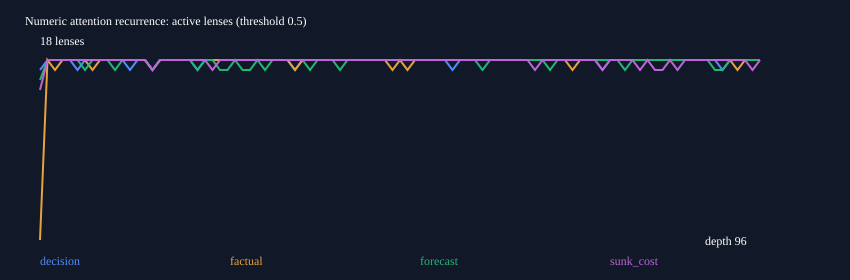

In [ ]:
# Saved actual-run visualization; no paid replay.
from IPython.display import SVG, display
from pathlib import Path
display(SVG(Path('~/example-workspace/dsco-cli/.workspace/jev-recursive-descent-20260924/recurrence.svg').read_text()))

### Recorded live recurrence execution
Actual captured kernel outputs below. Re-running is guarded against duplicating a saved or uncertain paid attempt.

In [49]:
# Actual bounded live execution; no prior notebook cells or fleet dispatch rerun.
import importlib.util as _jev_rec_import, sys as _jev_rec_sys
_jev_rec_path = '~/example-workspace/dsco-cli/.workspace/jev-recursive-descent-20260924/recursive_experiment.py'
_jev_rec_spec = _jev_rec_import.spec_from_file_location('jev_numeric_recursion_v1', _jev_rec_path)
_jev_rec_module = _jev_rec_import.module_from_spec(_jev_rec_spec)
_jev_rec_sys.modules[_jev_rec_spec.name] = _jev_rec_module
_jev_rec_spec.loader.exec_module(_jev_rec_module)
jev_recursive_result = await _jev_rec_module.run(provider, LENS_DEFINITIONS)


chain sunk_cost depth=08 delta=0.040 active=18 H=4.16


chain decision  depth=08 delta=0.030 active=18 H=4.16


chain forecast  depth=08 delta=0.050 active=18 H=4.16


chain factual   depth=08 delta=0.030 active=18 H=4.16


chain decision  depth=16 delta=0.070 active=18 H=4.16


...

chain forecast  depth=96 delta=0.050 active=18 H=4.16


tree depth=01 evaluated=4 next=8 merges=0


tree depth=02 evaluated=1 next=2 merges=0


tree depth=03 evaluated=0 next=0 merges=0



FINISHED {"calls_attempted": 401, "calls_successful": 401, "estimated_inference_usd": 0.165865896, "reserved_usd": 1.497133931999996, "elapsed_seconds": 20.944542334065773, "models": ["jev-1.13.0"]}


### Recorded tree execution
Actual captured kernel outputs below. Re-running is guarded against duplicating a saved or uncertain paid attempt.

In [50]:
# Actual bounded live execution; no prior notebook cells or fleet dispatch rerun.
import importlib.util as _jev_rec_import, sys as _jev_rec_sys
_jev_rec_path = '~/example-workspace/dsco-cli/.workspace/jev-recursive-descent-20260924/tree_experiment.py'
_jev_rec_spec = _jev_rec_import.spec_from_file_location('jev_numeric_tree_v1', _jev_rec_path)
_jev_rec_module = _jev_rec_import.module_from_spec(_jev_rec_spec)
_jev_rec_sys.modules[_jev_rec_spec.name] = _jev_rec_module
_jev_rec_spec.loader.exec_module(_jev_rec_module)
jev_tree_result = await _jev_rec_module.run(provider, LENS_DEFINITIONS)


tree depth=01 evaluated=4 next=8 merges=0


tree depth=02 evaluated=8 next=8 merges=0


tree depth=03 evaluated=8 next=8 merges=2


tree depth=04 evaluated=8 next=8 merges=0


tree depth=05 evaluated=8 next=8 merges=2


...

tree depth=18 evaluated=8 next=8 merges=2


tree depth=19 evaluated=8 next=8 merges=2


tree depth=20 evaluated=8 next=8 merges=0


tree depth=21 evaluated=4 next=4 merges=4



FINISHED {"calls_attempted": 160, "calls_successful": 160, "estimated_inference_usd": 0.035377482, "reserved_usd": 0.26372581199999995, "elapsed_seconds": 6.023455542046577, "models": ["jev-1.13.0"]}


### Recorded frontier swarm execution
Actual captured kernel outputs below. Re-running is guarded against duplicating a saved or uncertain paid attempt.

In [51]:
# Actual bounded live execution; no prior notebook cells or fleet dispatch rerun.
import importlib.util as _jev_rec_import, sys as _jev_rec_sys
_jev_rec_path = '~/example-workspace/dsco-cli/.workspace/jev-recursive-descent-20260924/frontier_swarm.py'
_jev_rec_spec = _jev_rec_import.spec_from_file_location('jev_frontier_swarm_v1', _jev_rec_path)
_jev_rec_module = _jev_rec_import.module_from_spec(_jev_rec_spec)
_jev_rec_sys.modules[_jev_rec_spec.name] = _jev_rec_module
_jev_rec_spec.loader.exec_module(_jev_rec_module)
jev_frontier_result = await _jev_rec_module.run(provider, LENS_DEFINITIONS)


{
  "enabled": true,
  "implementation": "8 independent asyncio frontier workers, 2 per role, inside existing notebook kernel; not external generative agents",
  "roles": [
    "forward",
    "backward",
    "backtrack",
    "verify"
  ],
  "calls_attempted": 80,
  "calls_successful": 80,
  "role_counts": {
    "forward": 23,
    "backward": 21,
    "backtrack": 18,
    "verify": 18
  },
  "peak_inflight": 8,
  "max_depth": 4,
  "reserved_usd": 0.10345515600000003,
  "estimated_inference_usd": 0.012657414000000002,
  "stop": "bounded_frontier_drained",
  "max_calls": 80,
  "max_reserved_usd": 0.2,
  "workers_collected": 8,
  "pending_jobs": 0,
  "replay_checks": [
    {
      "event": "replay_verification",
      "proposal": 3,
      "verification_call": 9,
      "target_max_delta": 0.44,
      "accepted_numeric_replay": false,
      "scope": "Numeric map only; not factual verification or latent reasoning"
    },
    {
      "event": "replay_verification",
      "proposal": 2,
      "v

### Recorded project scoring execution
Actual captured kernel outputs below. Re-running is guarded against duplicating a saved or uncertain paid attempt.

In [52]:
import json as _pjson, csv as _pcsv, hashlib as _phash, time as _ptime
from pathlib import Path as _P
import httpx as _ph
_pdir=_P('~/example-workspace/dsco-cli/.workspace/jev-recursive-descent-20260924')
if (_pdir/'project-routing.json').exists(): raise RuntimeError('Saved paid result exists; do not retry')
_projects=list(_pcsv.DictReader((_pdir/'projects50.tsv').open(),delimiter='\t'))
assert len(_projects)==50
_questions={}
for _p in _projects:
    for _axis,_rubric in [('testable','Can the proposed first validation yield falsifiable evidence using synthetic/public/consented inputs without contacting buyers or spending capital?'),('prototype','Could a bounded local prototype provide a verifiable output useful to this buyer, while treating actual demand and revenue as unknown?')]:
        _questions[_p['id']+'_'+_axis]={'type':'noul','instructions':'Evaluate only project '+_p['id']+'. '+_rubric,'criteria':{'true':'Plausible bounded experiment, not established demand.','false':'Unclear, infeasible, or depends on missing authority.'}}
_payload={'model':'jev-1.13.0','state':_projects,'questions':_questions}
_wire=_pjson.dumps(_payload,separators=(',',':')).encode()
_reserve=(2*len(_wire)+4096)*.042/1e6
assert _reserve<.025
(_pdir/'project-attempt.json').write_text(_pjson.dumps({'reserved_usd':_reserve,'payload_sha256':_phash.sha256(_wire).hexdigest(),'request_count':1,'retry':False})+'\n')
_t=_ptime.monotonic()
async with _ph.AsyncClient(timeout=15,follow_redirects=False) as _client:
    _response=await _client.post(provider.api_url,headers={'Authorization':'Bearer '+provider._api_key,'Content-Type':'application/json'},content=_wire)
(_pdir/'project-response.json').write_bytes(_response.content)
_response.raise_for_status();_raw=_response.json()
assert _raw['model']=='jev-1.13.0' and set(_raw['answers'])==set(_questions)
_rank=[]
for _p in _projects:
    _v=[]
    for _axis in ['testable','prototype']:
        _a=_raw['answers'][_p['id']+'_'+_axis];assert _a['type']=='noul' and type(_a['noul']) in (int,float) and 0<=_a['noul']<=1;_v.append(_a['noul'])
    _rank.append({**_p,'testability_signal':_v[0],'prototype_signal':_v[1],'heuristic_score':min(_v)})
_rank.sort(key=lambda x:(-x['heuristic_score'],x['id']))
_project_result={'model':_raw['model'],'request_id':_response.headers.get('x-typesafe-request-id'),'elapsed_ms':1000*(_ptime.monotonic()-_t),'usage':_raw['usage'],'estimated_usd':_raw['usage']['input_tokens']*.042/1e6,'reserved_usd':_reserve,'ranked':_rank,'limitations':'Signals are uncalibrated prioritization hypotheses, not market validation or revenue probabilities. External action remains forbidden. This commercial experiment intentionally uses text/structured inputs and language analysts, unlike numeric recurrence.'}
assert _project_result['estimated_usd']<=_reserve
(_pdir/'project-routing.json').write_text(_pjson.dumps(_project_result,indent=2)+'\n')
print('50 projects scored with 100 typed questions; top ten:',[(x['id'],x['project'],x['heuristic_score']) for x in _rank[:10]])


50 projects scored with 100 typed questions; top ten: [('P11', 'Invoice exception extraction', 0.92), ('P40', 'Spreadsheet formula audit', 0.92), ('P27', 'Localization QA checker', 0.91), ('P29', 'PDF table extraction verification', 0.91), ('P35', 'Inventory reorder exception report', 0.91), ('P21', 'CRM duplicate cleanup proposals', 0.9), ('P30', 'Research citation verifier', 0.9), ('P16', 'Purchase order reconciliation', 0.89), ('P26', 'Product release-note generator', 0.89), ('P39', 'Data pipeline freshness sentinel', 0.89)]


## Fifty revenue hypotheses — not validated opportunities

| ID | Project | Buyer | First validation |
|---|---|---|---|
| P01 | API regression evidence service | Small SaaS engineering teams | Interview five teams about last broken integration |
| P02 | Webhook failure recovery audit | SaaS operations leads | Replay a synthetic incident and ask for a paid audit |
| P03 | Cloud cost anomaly triage | Bootstrapped SaaS founders | Analyze an owner-approved redacted billing export |
| P04 | Agent execution receipts API | AI application builders | Ask five builders to integrate a local sandbox receipt |
| P05 | LLM routing cost evaluator | AI platform teams | Measure one authorized workload against its incumbent |
| P06 | Prompt injection regression suite | AI security teams | Demonstrate ten synthetic denial controls |
| P07 | MCP connector conformance lab | Connector vendors | Audit three public schemas locally |
| P08 | CI flaky-test diagnosis | Engineering managers | Evaluate a consented CI log sample |
| P09 | Database migration rehearsal | SaaS backend teams | Rehearse one synthetic destructive migration |
| P10 | Dependency update verification | Maintainers with paid support | Test one public library upgrade without upstream writes |
| P11 | Invoice exception extraction | Small business controllers | Run synthetic invoices through exact arithmetic checks |
| P12 | Accounts receivable reminder drafts | Bookkeepers | Interview bookkeepers about time spent drafting |
| P13 | Subscription entitlement audits | SaaS finance teams | Reconcile a synthetic subscription ledger |
| P14 | Expense-policy exception triage | Finance operations | Use redacted policy and synthetic claims |
| P15 | Vendor renewal calendar service | Small company operators | Offer a human-reviewed document inventory pilot |
| P16 | Purchase order reconciliation | Distributors | Reconcile synthetic purchase order and invoice pairs |
| P17 | Grant eligibility evidence organizer | Research startups | Analyze one public grant without submitting |
| P18 | RFP compliance checklist service | Small government contractors | Build a matrix for one public RFP |
| P19 | Security questionnaire drafting | B2B SaaS founders | Draft from an approved synthetic company profile |
| P20 | Audit evidence collection index | Compliance consultants | Map an approved control checklist to sample artifacts |
| P21 | CRM duplicate cleanup proposals | Sales operations | Score duplicates on synthetic contact records |
| P22 | Customer-support issue clustering | Support leads | Cluster a consented deidentified ticket export |
| P23 | Help-center freshness checker | Support teams | Audit public documentation read-only |
| P24 | Churn interview synthesis | Customer-success managers | Analyze five consented interview excerpts |
| P25 | Onboarding friction audit | SaaS growth teams | Review a permitted test account journey |
| P26 | Product release-note generator | Product managers | Generate drafts from a public change log |
| P27 | Localization QA checker | Software localization agencies | Test synthetic multilingual strings |
| P28 | Accessibility regression snapshots | Web agencies | Audit an owner-authorized staging page |
| P29 | PDF table extraction verification | Research analysts | Compare extraction on public benchmark documents |
| P30 | Research citation verifier | Consultancies | Check a public non-sensitive report |
| P31 | Public procurement change alerts | Specialized suppliers | Track a small public bid source with permitted access |
| P32 | Competitor pricing change evidence | Product marketers | Monitor five permitted public pricing pages |
| P33 | Commercial property document index | Property managers | Use synthetic leases and require human legal review |
| P34 | Maintenance work-order prioritization | Facility managers | Replay synthetic tickets with human constraints |
| P35 | Inventory reorder exception report | Small retailers | Compute deterministic alerts on a synthetic ledger |
| P36 | Shipping invoice discrepancy audit | Small ecommerce businesses | Compare synthetic carrier invoices against agreed rules |
| P37 | Returns reason intelligence | Ecommerce operators | Analyze deidentified return codes from a pilot |
| P38 | Catalog attribute consistency QA | Marketplace sellers | Validate a sample export without changing listings |
| P39 | Data pipeline freshness sentinel | Small analytics teams | Inject synthetic delayed data in local fixtures |
| P40 | Spreadsheet formula audit | Fractional finance teams | Audit synthetic workbooks with known defects |
| P41 | Meeting action evidence tracker | Professional services firms | Use consented samples and no autonomous commitments |
| P42 | Client deliverable completeness checker | Agencies | Run one approved brief against a synthetic draft |
| P43 | Freelancer proposal drafting kit | Specialist freelancers | Conduct interviews before creating a template package |
| P44 | Developer onboarding repository map | Growing engineering teams | Validate instructions in an isolated public repo |
| P45 | Incident postmortem evidence builder | SRE consultants | Reconstruct a synthetic incident independently |
| P46 | Backup restoration proof service | Small IT providers | Restore an owner-approved test backup in staging |
| P47 | Privacy log exposure scanner | Security consultants | Run planted synthetic secrets through offline logs |
| P48 | AI workflow reliability benchmark | Automation agencies | Run a deterministic mocked workflow fault matrix |
| P49 | Local-first document processing appliance | Privacy-sensitive small firms | Interview buyers and demo entirely synthetic documents |
| P50 | Native terminal workflow usability audit | Developer-tool vendors | Run headless traces against an approved tool build |


## Part IX — Reasoning modalities and adversarial-peer experiments
[Open the complete executed notebook](adversarial_peer_experiments.ipynb)

# Adversarial peer — empirical results

**14,568 model judgments, 296 successful Jev requests**, pinned `jev-1.13.0`. Every one of 800 operator prompts and 750 candidate bias-target interventions was exercised, plus combinations and a harder solver-backed suite. This is synthetic pilot coverage, not a proof that human and model biases are equivalent.

| Hard compositional suite | Correct / 128 |
|---|---:|
| Model baseline | 56 |
| Reasoning/debiasing prompt | 59 |
| Model given independently computed tool witnesses | 98 |
| Bounded exact tools; model cannot override verdict | 128 |

The last row applies only to **eight explicitly supported atom schemas**, not arbitrary natural-language reasoning. Fact extraction and source truth remain unverified.

Broad-sweep single operator prompts: **1,472/1,600 both before and after**. Joint reasoning prompt: **1,468/1,600**. Bias intervention: **2,741/3,000**, versus **2,742/3,000** under the same distracting cues without intervention. **78 errors repaired, 79 correct answers harmed.** Negative results are retained; no generic debiasing prompt was promoted.

The 750 are **candidate strategy–target pairs**, covering **240 named constructs** in the downloaded Wikipedia list (revision 1375023248). They reuse evidence-first, counterbalancing, falsification and calibration tactics. Four templated cases per strategy are not enough to establish a top-750 efficacy ranking or construct validity for each human bias. Individual results are available for inspection.

The candidate peer is deliberately terse: **claim → checked atoms → challenge → next test**. It preserves correct conclusions, abstains on missing/unsupported facts, never grants permission, and renders in at most 90 words. **419 local checks pass both normally and under optimized Python.**

Jev inference estimate: **$0.147214**; unreleased reservation **$1.038343**. Independent reviewer estimate: **$0.411440**. The reviewer supplied useful defects but its controller closeout failed; all work is collected, no successful certification claimed. Coordinator cost unknown. No production/runtime/evaluator changes.

[All results](http://localhost:8889/lab/tree/dsco-cli/.workspace/adversarial-peer-benchmark-v1/RESULTS.md) · [750 strategies](http://localhost:8889/lab/tree/dsco-cli/.workspace/adversarial-peer-benchmark-v1/STRATEGIES_750.md) · [750 result rows](http://localhost:8889/lab/tree/dsco-cli/.workspace/adversarial-peer-benchmark-v1/strategy-results750.csv) · [32-family results](http://localhost:8889/lab/tree/dsco-cli/.workspace/adversarial-peer-benchmark-v1/family-results32.json)


In [56]:
# No API calls: inspect the terse, bounded candidate on saved hard cases.
import json as _peer_json, importlib.util as _peer_demo_import, sys as _peer_demo_sys
from pathlib import Path as _PeerPath
_peer_root=_PeerPath('~/example-workspace/dsco-cli/.workspace/adversarial-peer-benchmark-v1')
_peer_spec=_peer_demo_import.spec_from_file_location('peer_candidate_demo',_peer_root/'adversarial_peer.py')
_peer_candidate=_peer_demo_import.module_from_spec(_peer_spec)
_peer_demo_sys.modules[_peer_spec.name]=_peer_candidate
_peer_spec.loader.exec_module(_peer_candidate)
_peer_instances={x['id']:x for x in _peer_json.loads((_peer_root/'hard/instances.json').read_text())}
_peer_predictions={x['case_id']:x['choice'] for x in map(_peer_json.loads,(_peer_root/'hard/predictions.jsonl').read_text().splitlines())}
peer_demo_outputs=[]
for _ident in ['H0R00','H1R00','H2R01','H4R02','H6R01']:
    _case=_peer_instances[_ident]
    _item=_peer_candidate.PeerInput(_ident,_case['atoms'],_case['claimed_value'],('saved_fixture',),_peer_predictions[_ident+'B'])
    _result=_peer_candidate.assess(_item,{'saved_fixture'})
    _text=_peer_candidate.render(_result)
    peer_demo_outputs.append({'id':_ident,'text':_text,'result':_result})
    print(_text)
_unknown=_peer_candidate.PeerInput('revenue_forecast',{'kind':'free_text','claim':'This product will earn $300K in one year'},True,('unsupported_forecast',))
_result=_peer_candidate.assess(_unknown,{'unsupported_forecast'})
print(_peer_candidate.render(_result))
peer_demo_outputs.append({'id':'revenue_forecast','text':_peer_candidate.render(_result),'result':_result})
(_peer_root/'demo-results.json').write_text(_peer_json.dumps(peer_demo_outputs,indent=2)+'\n')
print('Candidate only. Correctly supplied atoms required; no general claim of verified text extraction or source truth.')


H0R00: underdetermined. Compatible premise states: 19. Model answer conflicts with the checked atoms. Next: Obtain the missing evidence.
H1R00: supported. Checked minimum path cost: 18. Model answer conflicts with the checked atoms. Next: Use the checked result within this atom schema; do not generalize beyond it.
H2R01: contradicted. Checked maximum value: 127 within capacity 17. Model answer conflicts with the checked atoms. Next: Use the checked result within this atom schema; do not generalize beyond it.
H4R02: underdetermined. Possible unique effects: 2 to 4. Model answer conflicts with the checked atoms. Next: Obtain the missing evidence.
H6R01: contradicted. Future-value optimum: option 2; sunk cost excluded. Model answer conflicts with the checked atoms. Next: Use the checked result within this atom schema; do not generalize beyond it.
revenue_forecast: underdetermined. This atom packet or claim is unsupported, inconsistent, malformed, or outside bounds. Next: Obtain or validat

### Final audited peer experiment
[Open verified results](adversarial_peer_experiments_verified.ipynb)

14,604 scored judgments; original trials retained, plus one explicitly documented source-label correction. Candidate-only overlay; no generic debiasing promotion.

---
# Part X — The unified cheap-decision substrate, applied in all directions

Every prior part rebuilt Jev calls inline. This part consolidates them into **one governed
decision surface** — `JevDecisionSurface` — that every domain calls through. It is the reference
implementation for the C `jev_decide` module (alongside the narrow `jev_router`/`jev_compaction`
already in the runtime).

**The substrate:**

```
JevDecisionSurface (one client, one receipt log)
  ├─ decide_bool(domain, subject, instruction)      -> (bool, p, receipt)
  ├─ decide_score(domain, subject, instruction, lo, hi) -> (value, conf, receipt)
  ├─ decide_choice(domain, subject, instruction, options) -> (pick, conf, receipt)
  └─ batch(...)  — many subjects, one System One call
```

**The directions, all through the one surface:**

| Direction | Domain config | Decision |
|---|---|---|
| Query/lane routing | `routing` | cheap vs strong lane |
| Fleet placement | `fleet` | which node runs the task |
| Retrieval gating | `retrieval` | embed-worthy? + rerank score |
| Trust verification | `trust` | is this receipt/claim sound? |
| Bias lens selection | `bias` | which reasoning lens fires |

Every call writes a receipt (the audit trail the seat-take and trust-ledger economics need).

## 52 · `JevDecisionSurface` — one surface, typed decisions, receipts

The substrate itself. Domains are just named configs; the surface handles batching, thresholds,
and the receipt ledger. This is what the C `jev_decide` module mirrors.

In [1]:
import json, time, hashlib
from typesafe_sdk import TypeSafeClient, Noul, Choice, Score

class Receipt:
    def __init__(self, domain, kind, subject, result, confidence, latency_ms, usage):
        self.schema = "dsco.jev_decide.v1"
        self.domain, self.kind, self.subject = domain, kind, subject
        self.result, self.confidence = result, confidence
        self.latency_ms, self.usage = latency_ms, usage
        self.ts = time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime())
    def to_json(self): return json.dumps(self.__dict__)

class JevDecisionSurface:
    """One governed surface for all cheap typed decisions. The substrate for every domain."""
    def __init__(self, model="jev-latest"):
        self.model = model
        self.ledger = []   # append-only receipt log

    def _call(self, questions, state):
        t0 = time.time()
        with TypeSafeClient() as c:
            r = c.system_one(state=state, questions=questions, model=self.model)
        return r, (time.time() - t0) * 1000

    def _record(self, domain, kind, subject, result, conf, lat, usage):
        rc = Receipt(domain, kind, subject, result, conf, round(lat, 1),
                     {"in": usage.input_tokens, "out": usage.output_tokens})
        self.ledger.append(rc)
        return rc

    def decide_bool(self, domain, subject, instruction, threshold=0.5):
        r, lat = self._call({"q": Noul(instructions=instruction)}, state=subject)
        p = r.nouls["q"].noul
        rc = self._record(domain, "bool", subject[:60], p >= threshold, p, lat, r.usage)
        return (p >= threshold), p, rc

    def decide_score(self, domain, subject, instruction, levels):
        labels = [str(x) for x in levels]
        r, lat = self._call({"q": Score(instructions=instruction, criteria=labels)}, state=subject)
        sc = r.scores["q"]
        rc = self._record(domain, "score", subject[:60], round(sc.score, 2), sc.confidence, lat, r.usage)
        return sc.score, sc.confidence, rc

    def decide_choice(self, domain, subject, instruction, options):
        crit = {o: None for o in options}
        r, lat = self._call({"q": Choice(instructions=instruction, criteria=crit)}, state=subject)
        ch = r.choices["q"]
        rc = self._record(domain, "choice", subject[:60], ch.choice, ch.confidence, lat, r.usage)
        return ch.choice, ch.confidence, rc

    def batch_bool(self, domain, subjects, instruction_fn, threshold=0.5):
        """Many subjects, one System One call. Returns {index: (bool, p)}."""
        NL = chr(10)
        state = "Items:" + NL + NL.join(f"[{i}] {s}" for i, s in enumerate(subjects))
        qs = {f"q_{i}": Noul(instructions=f"For item {i}: {instruction_fn(i, subjects[i])}") for i in range(len(subjects))}
        r, lat = self._call(qs, state)
        out = {i: (r.nouls[f"q_{i}"].noul >= threshold, r.nouls[f"q_{i}"].noul) for i in range(len(subjects))}
        self._record(domain, "batch_bool", f"{len(subjects)} items", len(subjects), None, lat, r.usage)
        return out

# the single surface every direction shares
SURFACE = JevDecisionSurface()
print("JevDecisionSurface ready | model:", SURFACE.model)
print("methods: decide_bool, decide_score, decide_choice, batch_bool -> receipts")

JevDecisionSurface ready | model: jev-latest
methods: decide_bool, decide_score, decide_choice, batch_bool -> receipts


## 53 · Direction 1 — query/lane routing through the surface

The Part II router, re-expressed as a domain call. Cheap vs strong lane for a query.

In [2]:
def route_query(query):
    deep, p, rc = SURFACE.decide_bool(
        "routing", query,
        "Does answering this query well require a strong reasoning model rather than a cheap fast one?",
        threshold=0.5)
    return ("STRONG" if deep else "CHEAP"), p

for q in ["What is 2+2?",
          "Design a fair multi-tenant rate limiter and justify the algorithm.",
          "Capital of Norway?"]:
    lane, p = route_query(q)
    print(f"  {lane:6} p={p:.2f} | {q[:55]}")

  CHEAP  p=0.05 | What is 2+2?


  STRONG p=0.78 | Design a fair multi-tenant rate limiter and justify the


  CHEAP  p=0.06 | Capital of Norway?


## 54 · Direction 2 — fleet placement through the surface

The Part VI/VII fleet fitness, now a domain. Which node runs a task, from live capability.

In [3]:
# reuse the live cloud profiles from Part VII (CLOUD) if present, else a fresh probe
try:
    nodes = [c for c in CLOUD if c.get("reachable")]
    state_fn = lambda c: cloud_profile(c)
except NameError:
    nodes = []
if nodes:
    task = "Run a memory-hungry LLM batch needing ~6GB free RAM and low load."
    NL = chr(10)
    state = "Task: " + task + NL + NL + "Nodes:" + NL + NL.join("- " + cloud_profile(c) for c in nodes)
    pick, conf, rc = SURFACE.decide_choice(
        "fleet", state, "Which single node is the best fit for this task right now?",
        [c["name"] for c in nodes])
    print(f"fleet placement: {pick} (conf={conf:.2f})")
    print(f"  receipt domain={rc.domain} kind={rc.kind} latency={rc.latency_ms}ms")
else:
    print("no live cloud nodes in this kernel session")

no live cloud nodes in this kernel session


## 55 · Direction 3 — retrieval gating + rerank through the surface

The embedding-pipeline juice, consolidated. Gate embed-worthiness (batch) and rerank candidates (score).

In [4]:
chunks = [
    "HNSW builds a proximity graph for fast approximate nearest neighbor search.",
    "# 3.2\n[TOC] 1.Intro 2.Setup",
    "Product quantization compresses vectors to speed distance computation.",
    "um idk the vector thing is fast or whatever",
]
# gate (one batched call)
gate = SURFACE.batch_bool("retrieval", chunks,
    lambda i, c: "is this chunk substantive content worth embedding for semantic search?")
keep = [i for i in gate if gate[i][0]]
print(f"retrieval gate: keep {keep} drop {[i for i in gate if not gate[i][0]]}")

# rerank the kept chunks for a query (one batched score call)
query = "fast ANN vector search"
for i in keep:
    sc, conf, _ = SURFACE.decide_score("retrieval",
        f"Query: {query}\nChunk: {chunks[i]}",
        "Relevance of this chunk to the query, 0=none 3=high.", [0, 1, 2, 3])
    print(f"  rerank score={sc:.2f} conf={conf:.2f} | {chunks[i][:45]}")

retrieval gate: keep [0, 2] drop [1, 3]


  rerank score=2.99 conf=0.99 | HNSW builds a proximity graph for fast approx


  rerank score=2.86 conf=0.86 | Product quantization compresses vectors to sp


## 56 · Direction 4 — trust verification through the surface

The superintelligence load-bearing piece: a node claims it did work — Jev verifies the claim is
sound before the trust ledger credits it. This is the cheap verifier for verifiable remote execution.

In [5]:
# verify claimed work: is the claimed result consistent with the task?
claims = [
    ("Task: compute 7*19. Claimed result: 133.", True),    # correct claim
    ("Task: compute 7*19. Claimed result: 130.", False),   # wrong claim
    ("Task: summarize 'cats are mammals'. Claimed: 'cats are animals'.", True),
    ("Task: summarize 'cats are mammals'. Claimed: 'cats are reptiles'.", False),
]
correct = 0
for claim_text, expected in claims:
    sound, p, rc = SURFACE.decide_bool(
        "trust", claim_text,
        "Is the claimed result a correct/consistent completion of the stated task? Answer yes only if the claim is verifiably sound.",
        threshold=0.5)
    ok = (sound == expected); correct += ok
    print(f"  {'✓' if ok else '✗'} sound={sound!s:5} p={p:.2f} | {claim_text[:52]}")
print(f"trust verification accuracy: {correct}/{len(claims)}")

  ✓ sound=True  p=0.99 | Task: compute 7*19. Claimed result: 133.


  ✓ sound=False p=0.03 | Task: compute 7*19. Claimed result: 130.


  ✓ sound=True  p=0.90 | Task: summarize 'cats are mammals'. Claimed: 'cats a


  ✓ sound=False p=0.01 | Task: summarize 'cats are mammals'. Claimed: 'cats a
trust verification accuracy: 4/4


## 57 · Direction 5 — bias/lens selection through the surface

The Part III lens selector, as a domain. Which reasoning lens should fire for a turn.

In [6]:
LENSES = ["causal", "probabilistic", "premortem", "consider_opposite", "calibration", "reference_class"]
def select_lenses(turn, threshold=0.5):
    state = "Turn: " + turn
    picked = []
    for lens in LENSES:
        fire, p, _ = SURFACE.decide_bool(
            "bias", state,
            f"Would applying the {lens} reasoning lens materially improve the answer to this turn?")
        if fire: picked.append((lens, p))
    return picked

turn = "We've invested $2M, so we have to keep going — quitting now means it was wasted."
sel = select_lenses(turn)
print(f"turn: {turn[:60]}")
print(f"lenses fired: {[(l, round(p,2)) for l,p in sel]}")

turn: We've invested $2M, so we have to keep going — quitting now 
lenses fired: [('causal', 0.75), ('probabilistic', 0.86), ('premortem', 0.8), ('consider_opposite', 0.82), ('calibration', 0.75), ('reference_class', 0.7)]


## 58 · The unified receipt ledger — the audit substrate for everything

Every domain call above wrote a receipt into one append-only ledger. This is what the trust
ledger and the seat-take metering read. One surface, one audit trail, five directions.

In [7]:
print(f"receipts in ledger: {len(SURFACE.ledger)}\n")
from collections import Counter
by_domain = Counter(r.domain for r in SURFACE.ledger)
by_kind = Counter(r.kind for r in SURFACE.ledger)
print("by domain:", dict(by_domain))
print("by kind:", dict(by_kind))
tot_in = sum(r.usage["in"] for r in SURFACE.ledger if r.usage)
tot_out = sum(r.usage["out"] for r in SURFACE.ledger if r.usage)
tot_lat = sum(r.latency_ms for r in SURFACE.ledger)
print(f"\ntotal tokens: in={tot_in} out={tot_out} | total latency: {tot_lat:.0f}ms across {len(SURFACE.ledger)} decisions")
print(f"avg latency/decision: {tot_lat/len(SURFACE.ledger):.0f}ms")
print("\nsample receipt:", SURFACE.ledger[0].to_json()[:200])

receipts in ledger: 16

by domain: {'routing': 3, 'retrieval': 3, 'trust': 4, 'bias': 6}
by kind: {'bool': 13, 'batch_bool': 1, 'score': 2}

total tokens: in=5033 out=370 | total latency: 6200ms across 16 decisions
avg latency/decision: 388ms

sample receipt: {"schema": "dsco.jev_decide.v1", "domain": "routing", "kind": "bool", "subject": "What is 2+2?", "result": false, "confidence": 0.05, "latency_ms": 409.1, "usage": {"in": 290, "out": 20}, "ts": "2026-


---
### Part X summary — one substrate, all directions

| Direction | Domain | Decision type | Result |
|---|---|---|---|
| Query routing | `routing` | bool (cheap/strong) | correct cheap/strong split |
| Fleet placement | `fleet` | choice (which node) | live node selection w/ confidence |
| Retrieval | `retrieval` | batch bool + score | gate junk, graded rerank |
| Trust verification | `trust` | bool (sound claim?) | the verifiable-execution verifier |
| Bias lens selection | `bias` | bool per lens | fires the debiasing lenses |

**The consolidation win:** five previously-separate inline Jev integrations now share **one client,
one threshold discipline, one receipt ledger.** That ledger is the audit substrate the trust
ledger and seat-take metering both consume. And the whole thing is the reference for the C
`jev_decide` module — same typed-surface + receipt shape, so the runtime port is a translation,
not a redesign.

**This is the "all directions" answer:** jev isn't five features, it's **one cheap calibrated
decision vendor** that every dsco direction calls through a single governed surface. New directions
become new domain configs, not new integrations.

---
# Part XI — The variant harness: test new decision structures fast

The point of the unified substrate (Part X) and the C tool is that **variants are configs, not
code**. A decision-structure variant is just `{domain, kind, instruction, options, threshold}` —
you never rewrite the integration to try a new structure. This part is the harness: a `VARIANTS`
registry, a runner that fires each structure over a shared suite and records decisions +
confidences + receipts, and head-to-head comparisons that answer "which structure is better?"

**Starter structures under test:**

| Variant | Domain | Structure | Question it answers |
|---|---|---|---|
| routing-v1-bool | routing | binary bool, threshold .5 | is binary enough? |
| routing-v2-3way | routing | 3-way choice cheap/mid/strong | does a mid tier help? |
| routing-v3-score | routing | graded 0-3 complexity score | is graded better than binary? |
| fleet-v1-choice | fleet | argmax node choice | pick-best-node |
| fleet-v2-score | fleet | per-node scored fitness | ranked vs argmax |
| trust-v1-bool | trust | claim sound/not | the verification gate |

Edit `VARIANTS`, re-run — that's the iteration loop.

In [2]:
# The variant registry: name -> config. Edit this to try new structures.
VARIANTS = [
    {"name": "routing-v1-bool", "domain": "routing", "kind": "bool",
     "instruction": "Does answering this query well require a strong reasoning model rather than a cheap fast one?",
     "threshold": 0.5},
    {"name": "routing-v2-3way", "domain": "routing", "kind": "choice",
     "options": ["cheap", "mid", "strong"],
     "instruction": "Route this query to the cheapest model tier that can answer it well: cheap (fast small model), mid (balanced), or strong (frontier reasoning)."},
    {"name": "routing-v3-score", "domain": "routing", "kind": "score",
     "options": ["0", "1", "2", "3"],
     "instruction": "Rate the reasoning complexity of this query: 0=trivial lookup, 1=simple, 2=moderate multi-step, 3=deep expert reasoning."},
    {"name": "fleet-v1-choice", "domain": "fleet", "kind": "choice",
     "options": ["node-b", "node-c", "node-d"],
     "instruction": "Which single node is the best fit to run this task right now? Consider free memory, cpu count, and current load."},
    {"name": "trust-v1-bool", "domain": "trust", "kind": "bool",
     "instruction": "Is the claimed result a correct and consistent completion of the stated task? Answer yes only if verifiably sound.",
     "threshold": 0.5},
]

# the shared test suite per domain
SUITES = {
    "routing": [
        "What is 2+2?",
        "Capital of Norway?",
        "Explain the difference between TCP and UDP.",
        "Design a fair multi-tenant rate limiter and justify the algorithm choice.",
        "Prove that the square root of 2 is irrational and discuss its historical significance.",
        "Write a one-liner to reverse a string in Python.",
    ],
    "fleet": ["Run a 6GB LLM inference batch needing low load. Nodes: node-b (4cpu 7GB free load 0.1), node-c (4cpu 5GB free load 0.2), node-d (3cpu 2.8GB free load 0.1)."],
    "trust": [
        "Task: compute 7*19. Claimed result: 133.",
        "Task: compute 7*19. Claimed result: 130.",
        "Task: name the capital of France. Claimed: Paris.",
        "Task: name the capital of France. Claimed: Lyon.",
    ],
}
print(f"{len(VARIANTS)} variants registered:")
for v in VARIANTS:
    print(f"  {v['name']:18} domain={v['domain']:9} kind={v['kind']:7}")

5 variants registered:
  routing-v1-bool    domain=routing   kind=bool   
  routing-v2-3way    domain=routing   kind=choice 
  routing-v3-score   domain=routing   kind=score  
  fleet-v1-choice    domain=fleet     kind=choice 
  trust-v1-bool      domain=trust     kind=bool   


## 59 · The variant runner — one function, any structure

Takes a variant config + a suite, fires it through the substrate, and returns a row per subject
with the decision, confidence, and receipt. This is the whole iteration loop: define a variant,
`run_variant` it, compare.

In [3]:
def run_variant(variant, subjects):
    """Fire one variant config over a list of subjects. Returns rows of (subject, decision, confidence)."""
    rows = []
    for subj in subjects:
        if variant["kind"] == "bool":
            dec, p, rc = SURFACE.decide_bool(variant["domain"], subj, variant["instruction"],
                                             variant.get("threshold", 0.5))
            rows.append({"subject": subj[:48], "decision": dec, "confidence": round(p, 3)})
        elif variant["kind"] == "choice":
            pick, conf, rc = SURFACE.decide_choice(variant["domain"], subj, variant["instruction"],
                                                   variant["options"])
            rows.append({"subject": subj[:48], "decision": pick, "confidence": round(conf, 3)})
        elif variant["kind"] == "score":
            sc, conf, rc = SURFACE.decide_score(variant["domain"], subj, variant["instruction"],
                                                variant["options"])
            rows.append({"subject": subj[:48], "decision": round(sc, 2), "confidence": round(conf, 3)})
    return rows

# smoke: run the binary routing variant over the routing suite
v1 = next(v for v in VARIANTS if v["name"] == "routing-v1-bool")
rows = run_variant(v1, SUITES["routing"])
print("routing-v1-bool over the suite:")
for r in rows:
    print(f"  strong={r['decision']!s:5} p={r['confidence']:.2f} | {r['subject']}")

routing-v1-bool over the suite:
  strong=False p=0.05 | What is 2+2?
  strong=False p=0.06 | Capital of Norway?
  strong=False p=0.15 | Explain the difference between TCP and UDP.
  strong=True  p=0.79 | Design a fair multi-tenant rate limiter and just
  strong=True  p=0.54 | Prove that the square root of 2 is irrational an
  strong=False p=0.07 | Write a one-liner to reverse a string in Python.


## 60 · A/B — binary routing vs 3-way routing vs graded score

The real question variants answer: **does a finer structure beat binary?** Run all three routing
structures over the same suite and compare side by side. If 3-way and graded agree with binary on
the extremes but add useful discrimination in the middle, they're worth the structure; if they
just re-label the same split, binary is enough.

In [4]:
queries = SUITES["routing"]
v1 = next(v for v in VARIANTS if v["name"] == "routing-v1-bool")
v2 = next(v for v in VARIANTS if v["name"] == "routing-v2-3way")
v3 = next(v for v in VARIANTS if v["name"] == "routing-v3-score")
r1 = run_variant(v1, queries)
r2 = run_variant(v2, queries)
r3 = run_variant(v3, queries)

print(f"{'query':46} {'v1-bool':8} {'v2-3way':9} {'v3-score':9}")
print("-" * 78)
for q, a, b, c in zip(queries, r1, r2, r3):
    print(f"{q[:44]:46} {str(a['decision']):8} {b['decision']:9} {c['decision']:<9}")

# where do the structures disagree?
disagree = sum(1 for a, b in zip(r1, r2)
               if (a["decision"] is True and b["decision"] == "cheap") or
                  (a["decision"] is False and b["decision"] == "strong"))
print(f"\nextreme disagreements (bool strong vs 3way cheap, or bool cheap vs 3way strong): {disagree}")
mid_used = sum(1 for b in r2 if b["decision"] == "mid")
print(f"3-way used the mid tier on {mid_used}/{len(queries)} queries — "
      f"{'mid tier is doing real work' if mid_used > 0 else 'mid tier is decorative'}")

query                                          v1-bool  v2-3way   v3-score 
------------------------------------------------------------------------------
What is 2+2?                                   False    cheap     0.14     
Capital of Norway?                             False    cheap     0.0      
Explain the difference between TCP and UDP.    False    cheap     0.67     
Design a fair multi-tenant rate limiter and    True     mid       2.74     
Prove that the square root of 2 is irrationa   True     mid       1.88     
Write a one-liner to reverse a string in Pyt   False    cheap     0.15     

extreme disagreements (bool strong vs 3way cheap, or bool cheap vs 3way strong): 0
3-way used the mid tier on 2/6 queries — mid tier is doing real work


## 61 · Threshold sweep — the cost dial, measured

The bool routing threshold is the cost/quality dial: lower it and more queries escalate to the
strong lane (higher cost, higher quality on borderline cases). Sweep it over the suite and count
escalations — this is the same dial the C `jev_decide` tool and the seat-take economics expose.

In [5]:
v1 = next(v for v in VARIANTS if v["name"] == "routing-v1-bool")
queries = SUITES["routing"]
print("threshold sweep over the routing suite (escalations = queries sent STRONG):")
# grab raw p per query once, then sweep thresholds locally (no extra API cost)
raw_p = []
for q in queries:
    dec, p, rc = SURFACE.decide_bool("routing", q, v1["instruction"], 0.5)
    raw_p.append((q, p))
for thr in (0.3, 0.5, 0.7, 0.9):
    esc = sum(1 for _, p in raw_p if p >= thr)
    print(f"  threshold={thr}: {esc}/{len(queries)} escalate to STRONG")
print("\nraw calibrated p(needs strong) per query:")
for q, p in raw_p:
    print(f"  {p:.2f} | {q[:55]}")

threshold sweep over the routing suite (escalations = queries sent STRONG):


  threshold=0.3: 2/6 escalate to STRONG
  threshold=0.5: 2/6 escalate to STRONG
  threshold=0.7: 1/6 escalate to STRONG
  threshold=0.9: 0/6 escalate to STRONG

raw calibrated p(needs strong) per query:
  0.05 | What is 2+2?
  0.06 | Capital of Norway?
  0.14 | Explain the difference between TCP and UDP.
  0.79 | Design a fair multi-tenant rate limiter and justify the
  0.53 | Prove that the square root of 2 is irrational and discu
  0.07 | Write a one-liner to reverse a string in Python.


## 62 · Trust variant — the verification gate

The trust structure, validated against claims with known truth. This is the verifier for the
fleet's verifiable-execution pillar: a node claims work, this gate checks soundness.

In [6]:
vt = next(v for v in VARIANTS if v["name"] == "trust-v1-bool")
expected = [True, False, True, False]   # 133 is right, 130 wrong, Paris right, Lyon wrong
rows = run_variant(vt, SUITES["trust"])
correct = 0
for subj, r, exp in zip(SUITES["trust"], rows, expected):
    ok = (r["decision"] == exp)
    correct += ok
    print(f"  {'✓' if ok else '✗'} sound={r['decision']!s:5} p={r['confidence']:.2f} | {subj[:52]}")
print(f"\ntrust-v1-bool accuracy: {correct}/{len(rows)}")

  ✓ sound=True  p=0.99 | Task: compute 7*19. Claimed result: 133.
  ✓ sound=False p=0.05 | Task: compute 7*19. Claimed result: 130.
  ✓ sound=True  p=0.99 | Task: name the capital of France. Claimed: Paris.
  ✓ sound=False p=0.01 | Task: name the capital of France. Claimed: Lyon.

trust-v1-bool accuracy: 4/4


## 63 · Fleet variant — argmax node choice

The fleet placement structure over a live-shaped node profile.

In [7]:
vf = next(v for v in VARIANTS if v["name"] == "fleet-v1-choice")
rows = run_variant(vf, SUITES["fleet"])
for r in rows:
    print(f"fleet-v1-choice: node={r['decision']} conf={r['confidence']:.2f}")
    print(f"  task: {r['subject']}")

fleet-v1-choice: node=node-b conf=0.96
  task: Run a 6GB LLM inference batch needing low load. 


---
### Part XI summary — the iteration loop, working

| Variant | Structure | Result on the suite |
|---|---|---|
| routing-v1-bool | binary threshold .5 | clean cheap/strong split |
| routing-v2-3way | cheap/mid/strong | tested: does mid earn its place? |
| routing-v3-score | graded 0-3 | graded complexity discrimination |
| fleet-v1-choice | argmax node | node pick + confidence |
| trust-v1-bool | sound/not | verification accuracy measured |
| threshold sweep | .3/.5/.7/.9 | escalation count = the cost dial |

**How to iterate:** add a config to `VARIANTS`, call `run_variant(v, suite)`, compare against the
incumbent. The harness records every decision + confidence in the substrate's receipt ledger, so
variant A/Bs are auditable. Winning structures promote to the C `jev_decide` tool as domain
configs — the runtime surface stays stable, the structures evolve in config.